# AI Referee V4 — tracked video + YOLO pose contact (Colab)
**Team: Sahayu R · Rishi D · Shashank R · Brian L · Abhinav K · Ishmeet S**

Upload any picture (or paste an image URL) and your fine-tuned RF-DETR tells you
what it sees: draws boxes and prints a plain-language verdict. Inference runs on
Roboflow's servers — no GPU runtime needed, nothing is trained or changed.

**V2 pose-aware judge:** your RF-DETR detector finds *who* is involved; a second
classifier (ResNet-18, trained on clean-vs-foul tackle images) rules *whether*
the tackle is clean (ball won first) or a foul. When they disagree, the verdict
is flagged for human review instead of guessing.

The trained detector and classifiers are unchanged. The old box-overlap
contact gate is replaced by multi-person YOLOv8m-Pose keypoints and normalized
limb-to-limb distance. This V3 geometry has **not yet been benchmarked**, so the
older end-to-end accuracy figures must not be quoted for this notebook until a
held-out comparison is run.

A third model screens for **handball** (92% balanced on small test sets).
Its training data has NO goalkeeper labels, so it cannot apply the keeper
exemption — every handball flag is marked needs-human-review by design.

Not a general image classifier: upload a cat and the honest answer is
"nothing recognized".

*Clean/foul training data includes the VarCNN dataset — credit: Aamir Ahmad
Ansari, github.com/aamir09/VarCnn.*
**Important:** Roboflow boxes are still used internally to associate YOLO poses
with the detected fouling player and victim. They no longer decide whether
contact occurred and are not drawn; the visible geometry is the pose skeleton.

V3 uses the existing pretrained `yolov8m-pose.pt` multi-person model. It selects
two distinct incident players jointly, so one player cannot be assigned to
both roles. No pose fine-tuning is required to run this version.

## V4 video system
Video no longer trusts the experimental binary checkpoint. It tracks stable
player IDs through the clip, identifies the fouling player and victim once
with Roboflow, measures sustained limb contact, and votes the existing image
classifiers across the contact window. A missing track or disagreement becomes
`NEEDS REVIEW`, never a confident guess.


## 1. Setup

In [ ]:
import os, getpass, sys
!mkdir -p /content/ai-referee/src/airef/models
%cd /content/ai-referee
!pip -q install opencv-python-headless matplotlib numpy av ultralytics 'lap>=0.5.12'

# Ultralytics downloads the standard pretrained multi-person pose weights once.
from ultralytics import YOLO
YOLO('yolov8m-pose.pt')
print('YOLOv8m-Pose multi-person model ready')

sys.path.insert(0, 'src')
os.environ['ROBOFLOW_API_KEY'] = getpass.getpass('Roboflow PRIVATE API key: ')
print('key set for this session only — not written to disk')


/content/ai-referee
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8m-Pose multi-person model ready
Roboflow PRIVATE API key: ··········
key set for this session only — not written to disk


## 2. Project files (tested code)

In [ ]:
%%writefile src/airef/__init__.py
"""AI Referee: automated soccer violation detection from video clips."""

__version__ = "0.1.0"


Writing src/airef/__init__.py


In [ ]:
%%writefile src/airef/device.py
"""Device selection: CUDA (Colab) / MPS (Apple Silicon) / CPU.

Kept in one place so training, evaluation and inference agree. Apple's MPS
backend has no GradScaler and no stable fp16 autocast, so mixed precision is
enabled for CUDA only — on MPS we train in fp32, which is what the M-series
unified memory wants anyway.
"""
from __future__ import annotations

import os

import torch


def pick_device(prefer: str | None = None) -> str:
    """Return 'cuda', 'mps' or 'cpu'.

    Override with the AIREF_DEVICE env var (e.g. AIREF_DEVICE=cpu) when the
    MPS path misbehaves on a particular op.
    """
    choice = prefer or os.environ.get("AIREF_DEVICE")
    if choice:
        return choice
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def amp_enabled(device: str) -> bool:
    """Mixed precision is CUDA-only here (see module docstring)."""
    return device == "cuda"


def pin_memory(device: str) -> bool:
    """pin_memory only means anything for CUDA host->device copies."""
    return device == "cuda"


def dataloader_workers(device: str) -> int:
    """macOS spawns (not forks) workers; 2 is fine and keeps decode off the main thread."""
    return 2


Writing src/airef/device.py


In [ ]:
%%writefile src/airef/roboflow_client.py
"""Binary foul / no-foul detection via the team's Roboflow workflow (REST).

Why REST and not the official `inference-sdk`: every published inference-sdk
release requires Python < 3.13 and this project runs 3.13, so the SDK cannot
be installed. The serverless REST endpoint is Roboflow's documented fallback
and needs no extra dependencies.

Why the child workflow and not the "...Logic" wrapper: the wrapper
(football-foul-detection-vfootball-foul-detection-u1r8g-1-rfdetr-medium-t1-logic)
is broken server-side — its inner_workflow step binds a `model_id` parameter
that the child workflow does not declare, so every run returns HTTP 500
(InnerWorkflowParameterBindingsUnknownInputError). The child workflow
`football-foul-detection-u1r8g` is the actual model run and works. Fix the
wrapper in the Roboflow UI and you can pass its slug via `workflow_id=`.

The API key comes from the ROBOFLOW_API_KEY environment variable, or from a
git-ignored `.env` file at the repo root. Never hardcode or commit it.

Grounded response shape (captured from a real run, 2026-07-18 — see
runs/roboflow_ground/):

    {"outputs": [{"predictions": {
        "image": {"width": W, "height": H},
        "predictions": [{"x":..,"y":..,"width":..,"height":..,
                         "confidence":..,"class":"fouling_player"|"victim"|"foul",
                         "class_id":..,"detection_id":..,"parent_id":..}, ...]}}],
     "profiler_trace": []}
"""
from __future__ import annotations

import base64
import json
import os
import time
import urllib.error
import urllib.request
from dataclasses import dataclass, field
from pathlib import Path

API_URL = "https://serverless.roboflow.com"
WORKSPACE = "ishmeet-singh-csaoh"
DEFAULT_WORKFLOW = "football-foul-detection-u1r8g"

# Soccer-specific ball detector (RF-DETR-small). The "...-logic" wrapper works
# for this one, but we target the child workflow for consistency with the foul
# client and to avoid the inner_workflow binding class of bug.
BALL_WORKFLOW = "soccer-ball-detection-2-teahj"

# Detection classes that signal a foul event (the model also emits "victim").
FOUL_CLASSES = frozenset({"foul", "fouling_player"})


class RoboflowError(RuntimeError):
    """Request or response-shape failure talking to Roboflow."""


class RoboflowAuthError(RoboflowError):
    """Bad or missing API key."""


@dataclass
class Detection:
    cls: str
    confidence: float
    x: float
    y: float
    width: float
    height: float


@dataclass
class FoulCall:
    """Binary verdict for one image.

    confidence is a heuristic: the strongest foul-class detection when foul,
    else 1 - the strongest sub-threshold foul-class detection (1.0 if none).
    """
    foul: bool
    confidence: float
    detections: list[Detection] = field(default_factory=list)
    image_wh: tuple[int, int] = (0, 0)


def _api_key() -> str:
    key = os.environ.get("ROBOFLOW_API_KEY")
    if not key:
        env_file = Path(__file__).resolve().parents[2] / ".env"
        if env_file.exists():
            for line in env_file.read_text().splitlines():
                name, _, value = line.strip().partition("=")
                if name == "ROBOFLOW_API_KEY" and value:
                    key = value.strip().strip("'\"")
                    break
    if not key:
        raise RoboflowAuthError(
            "ROBOFLOW_API_KEY not set (env var or .env at the repo root). "
            "Get it at app.roboflow.com/settings/api."
        )
    return key


def _to_base64(image: str | Path | bytes) -> str:
    data = image if isinstance(image, bytes) else Path(image).read_bytes()
    return base64.b64encode(data).decode()


def run_foul_workflow(
    image: str | Path | bytes,
    workflow_id: str = DEFAULT_WORKFLOW,
    timeout: float = 60.0,
    retries: int = 2,
) -> tuple[list[Detection], tuple[int, int]]:
    """Run one image through the workflow; return (detections, (width, height)).

    Retries transient failures (network errors, HTTP 5xx) with exponential
    backoff. 4xx errors don't retry; 401/403 raise RoboflowAuthError.
    """
    body = json.dumps({
        "api_key": _api_key(),
        "inputs": {"image": {"type": "base64", "value": _to_base64(image)}},
    }).encode()
    url = f"{API_URL}/{WORKSPACE}/workflows/{workflow_id}"

    last_err: Exception | None = None
    for attempt in range(retries + 1):
        try:
            req = urllib.request.Request(
                url, data=body, headers={"Content-Type": "application/json"}
            )
            with urllib.request.urlopen(req, timeout=timeout) as r:
                resp = json.load(r)
            break
        except urllib.error.HTTPError as e:
            detail = e.read().decode(errors="replace")[:300]
            if e.code in (401, 403):
                raise RoboflowAuthError(f"HTTP {e.code}: {detail}") from e
            if 400 <= e.code < 500:
                raise RoboflowError(f"HTTP {e.code}: {detail}") from e
            last_err = RoboflowError(f"HTTP {e.code}: {detail}")
        except (urllib.error.URLError, TimeoutError, json.JSONDecodeError) as e:
            last_err = RoboflowError(f"request failed: {e}")
        if attempt < retries:
            time.sleep(0.5 * 2 ** attempt)
    else:
        raise last_err  # type: ignore[misc]

    # Defensive parse against the grounded shape; never assume, never keep blobs.
    try:
        block = resp["outputs"][0]["predictions"]
        # width/height come back as null (not absent) when the model finds
        # nothing in the image, so `or {}` / `or 0` — not .get defaults.
        img = block.get("image") or {}
        raw = block["predictions"]
    except (KeyError, IndexError, TypeError) as e:
        keys = list(resp)[:8] if isinstance(resp, dict) else type(resp).__name__
        raise RoboflowError(f"unexpected response shape (top-level: {keys})") from e

    dets = [
        Detection(
            cls=str(p.get("class", "?")),
            confidence=float(p.get("confidence", 0.0)),
            x=float(p.get("x", 0.0)), y=float(p.get("y", 0.0)),
            width=float(p.get("width", 0.0)), height=float(p.get("height", 0.0)),
        )
        for p in raw
    ]
    return dets, (int(img.get("width") or 0), int(img.get("height") or 0))


@dataclass
class BallDetection:
    confidence: float
    x: float
    y: float
    width: float
    height: float


def detect_ball(
    image: str | Path | bytes,
    threshold: float = 0.4,
    workflow_id: str = BALL_WORKFLOW,
    timeout: float = 60.0,
    retries: int = 2,
) -> BallDetection | None:
    """Locate the soccer ball with the team's RF-DETR ball model.

    Returns the highest-confidence ball at/above `threshold`, or None. Grounded
    on the real response (2026-07-20): same envelope as the foul workflow —
    outputs[0].predictions.predictions[], with image width/height null when
    nothing is found.

    Replaces the generic COCO detector, which hallucinated balls below 0.2 and
    could not see a ball pressed against a body (measured: 0.13 on a real
    handball). This model scores that same case at 0.51.
    """
    dets, _ = run_foul_workflow(image, workflow_id=workflow_id,
                                timeout=timeout, retries=retries)
    balls = [d for d in dets if d.confidence >= threshold]
    if not balls:
        return None
    b = max(balls, key=lambda d: d.confidence)
    return BallDetection(b.confidence, b.x, b.y, b.width, b.height)


def classify_foul(
    image: str | Path | bytes,
    threshold: float = 0.5,
    workflow_id: str = DEFAULT_WORKFLOW,
) -> FoulCall:
    """Binary foul / no-foul call for one image.

    Rule: FOUL iff any detection of a class in FOUL_CLASSES has
    confidence >= threshold. Tune the threshold on labeled frames (see
    ai_referee_roboflow_binary.ipynb) before trusting the verdicts.
    """
    dets, wh = run_foul_workflow(image, workflow_id=workflow_id)
    foul_scores = [d.confidence for d in dets if d.cls in FOUL_CLASSES]
    hits = [s for s in foul_scores if s >= threshold]
    if hits:
        return FoulCall(True, max(hits), dets, wh)
    return FoulCall(False, 1.0 - max(foul_scores, default=0.0), dets, wh)


Writing src/airef/roboflow_client.py


In [ ]:
%%writefile src/airef/tackle_classifier.py
"""Second-stage clean/foul tackle classifier for the foul checker.

ResNet-18 fine-tuned (locally, 2026-07-18) on a domain-mixed set:
- VarCNN clean/foul tackle crops — credit: Aamir Ahmad Ansari,
  github.com/aamir09/VarCnn (free use with attribution)
- the team's own Roboflow foul images (train split only)
- locally-held clean-challenge frames

Verified on four held-out sets: balanced accuracy 92.8% overall;
~83-90% within VarCNN, where both classes share one camera style (the more
conservative and more honest estimate — see session notes).

The detector (roboflow_client) answers WHO is involved; this model answers
WHETHER the tackle is clean (ball won first) or a foul.
"""
from __future__ import annotations

import io
from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

from .device import pick_device

DEFAULT_WEIGHTS = Path(__file__).resolve().parents[2] / "runs/clean_tackle/resnet18_mixed.pt"

_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

_model: nn.Module | None = None
_classes: list[str] = []
_device = "cpu"


def load_classifier(weights: str | Path = DEFAULT_WEIGHTS) -> None:
    """Load weights once; later classify_tackle calls reuse them."""
    global _model, _classes, _device
    weights = Path(weights)
    if not weights.exists():
        raise FileNotFoundError(
            f"classifier weights not found at {weights} — "
            "copy runs/clean_tackle/resnet18_mixed.pt there first."
        )
    _device = pick_device()
    ck = torch.load(weights, map_location=_device, weights_only=False)
    classes = list(ck["classes"])
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, len(classes))   # 2- or 3-class checkpoints
    m.load_state_dict(ck["state_dict"])
    m.to(_device).eval()
    _model, _classes = m, classes


def classify_tackle(image: str | Path | bytes) -> tuple[str, float]:
    """-> (class name, probability of that label)."""
    if _model is None:
        load_classifier()
    img = Image.open(io.BytesIO(image) if isinstance(image, (bytes, bytearray))
                     else image).convert("RGB")
    with torch.no_grad():
        probs = torch.softmax(_model(_tf(img)[None].to(_device))[0], dim=0)
    i = int(probs.argmax())
    return _classes[i], float(probs[i])


def classifier_classes() -> list[str]:
    if _model is None:
        load_classifier()
    return list(_classes)


def predict_proba_bgr(bgr_list, batch_size: int = 32):
    """Batched local inference on a list of BGR numpy frames (no API cost).

    Returns (probs, classes): probs is an (N, C) array of softmax
    probabilities aligned to the returned class-name list. Used by the video
    judge to score EVERY frame of a clip locally.
    """
    import cv2
    import numpy as np

    if _model is None:
        load_classifier()
    out = []
    for i in range(0, len(bgr_list), batch_size):
        chunk = bgr_list[i:i + batch_size]
        xs = torch.stack([
            _tf(Image.fromarray(cv2.cvtColor(b, cv2.COLOR_BGR2RGB))) for b in chunk
        ]).to(_device)
        with torch.no_grad():
            out.append(torch.softmax(_model(xs), dim=1).cpu().numpy())
    return np.concatenate(out) if out else np.empty((0, len(_classes))), list(_classes)


Writing src/airef/tackle_classifier.py


In [ ]:
%%writefile src/airef/severity.py
"""
Rule-based card severity estimator.

This module is NOT a trained red/yellow card classifier.
Instead, it combines evidence already produced by the AI Referee
pipeline to recommend:

- NO CARD
- YELLOW CARD
- POSSIBLE RED — NEEDS REVIEW
- NEEDS REVIEW
"""

from dataclasses import dataclass, field
import numpy as np


@dataclass
class SeverityResult:
    card: str = "NEEDS REVIEW"
    score: float = 0.0
    confidence: float = 0.0
    reasons: list = field(default_factory=list)


def estimate_card_severity(
    foul_probability,
    contact_probability,
    contact_duration,
    minimum_limb_gap,
    pose_contact_threshold=0.12,
    pose_reliable=True,
):
    """
    Estimate the most likely disciplinary action.

    Parameters
    ----------
    foul_probability:
        Output from the tackle classifier.

    contact_probability:
        Output from the contact classifier.

    contact_duration:
        Seconds of sustained contact.

    minimum_limb_gap:
        Smallest normalized limb distance measured by the pose tracker.

    pose_contact_threshold:
        Threshold already used inside video_judge.py.

    pose_reliable:
        Whether the pose estimate was considered reliable.
    """

    if not pose_reliable:
        return SeverityResult(
            card="NEEDS REVIEW",
            reasons=["Pose estimation was unreliable."]
        )

    foul_probability = float(np.clip(foul_probability, 0, 1))
    contact_probability = float(np.clip(contact_probability, 0, 1))

    # Smaller gap = stronger contact
    contact_depth = np.clip(
        (pose_contact_threshold - minimum_limb_gap)
        / max(pose_contact_threshold, 1e-6),
        0,
        1,
    )

    # Contact lasting ~0.30 seconds gets full credit
    duration_score = np.clip(contact_duration / 0.30, 0, 1)

    # Overall severity score
    severity_score = (
        0.45 * foul_probability +
        0.25 * contact_probability +
        0.15 * contact_depth +
        0.15 * duration_score
    )

    reasons = [
        f"Foul probability: {foul_probability:.0%}",
        f"Contact probability: {contact_probability:.0%}",
        f"Contact duration: {contact_duration:.2f}s",
        f"Minimum limb gap: {minimum_limb_gap:.3f}",
    ]

    if (
        severity_score >= 0.86
        and foul_probability >= 0.90
        and contact_probability >= 0.85
    ):
        return SeverityResult(
            card="POSSIBLE RED — NEEDS REVIEW",
            score=severity_score,
            confidence=0.89,
            reasons=reasons + [
                "Evidence is very strong, but the system cannot verify excessive force or studs."
            ],
        )

    if severity_score >= 0.62:
        return SeverityResult(
            card="YELLOW CARD",
            score=severity_score,
            confidence=severity_score,
            reasons=reasons,
        )

    return SeverityResult(
        card="NO CARD",
        score=severity_score,
        confidence=1 - severity_score,
        reasons=reasons,
    )

In [ ]:
%%writefile src/airef/handball_classifier.py
"""Handball spotter — third opinion in the foul-checker judge.

ResNet-18 fine-tuned (locally, 2026-07-18) on the team-provided
Football-Soccer-handball-classifier dataset (109 handball / 107 clean train
images) plus tackle and clean-challenge frames as extra no-handball negatives
(the 4x-larger negative pool is what cut false handball calls on tackle
images from 28% to ~5%).

Verified: 92.3% three-way balanced accuracy (handball 91% / clean 90% /
tackles-as-clean 95%), on small test sets (46+42+100) — expect ~±5% noise.

HONEST LIMIT: the training data has no goalkeeper labels, so this model
cannot apply the goalkeeper exemption, and no single frame shows intent or
deliberate-touch context. Treat every handball flag as needs-human-review.
"""
from __future__ import annotations

import io
from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

from .device import pick_device

DEFAULT_WEIGHTS = Path(__file__).resolve().parents[2] / "runs/handball/resnet18_handball_mixed.pt"

_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

_model: nn.Module | None = None
_classes: list[str] = []
_device = "cpu"


def load_handball(weights: str | Path = DEFAULT_WEIGHTS) -> None:
    global _model, _classes, _device
    weights = Path(weights)
    if not weights.exists():
        raise FileNotFoundError(
            f"handball weights not found at {weights} — "
            "copy runs/handball/resnet18_handball_mixed.pt there first."
        )
    _device = pick_device()
    ck = torch.load(weights, map_location=_device, weights_only=False)
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m.load_state_dict(ck["state_dict"])
    m.to(_device).eval()
    _model, _classes = m, list(ck["classes"])


def classify_handball(image: str | Path | bytes) -> tuple[str, float]:
    """-> ('handball' | 'no_handball', probability of that label)."""
    if _model is None:
        load_handball()
    img = Image.open(io.BytesIO(image) if isinstance(image, (bytes, bytearray))
                     else image).convert("RGB")
    with torch.no_grad():
        probs = torch.softmax(_model(_tf(img)[None].to(_device))[0], dim=0)
    i = int(probs.argmax())
    return _classes[i], float(probs[i])


Writing src/airef/handball_classifier.py


In [ ]:
%%writefile src/airef/contact.py
"""YOLOv8m-Pose contact gate + ball evidence for foul-checker V3.

V3 detects all people jointly with a pretrained multi-person pose model, then
selects two DISTINCT players for fouling_player and victim. Roboflow boxes help
associate roles and identify the incident region; they never provide contact
evidence. Contact comes only from normalized cross-player limb distance.

Honest limits:
- a single image cannot prove temporal "ball first" ordering;
- occluded joints are estimates and can still be wrong;
- the limb-distance threshold must be benchmarked on held-out soccer incidents.
If two distinct reliable poses cannot be selected, callers must request review.
"""
from __future__ import annotations

from dataclasses import dataclass, field

import cv2
import numpy as np

_pose_yolo = None
_ball_yolo = None
KP_MIN = 0.25

# COCO 17-keypoint layout used by YOLO pose:
# 0 nose; 5/6 shoulders; 7/8 elbows; 9/10 wrists;
# 11/12 hips; 13/14 knees; 15/16 ankles.
POSE_CONNECTIONS = (
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (5, 11), (6, 12), (11, 12),
    (11, 13), (13, 15), (12, 14), (14, 16),
)
CONTACT_SEGMENTS = POSE_CONNECTIONS
ARM_LANDMARKS = (5, 6, 7, 8, 9, 10)


def _pose_model():
    global _pose_yolo
    if _pose_yolo is None:
        from ultralytics import YOLO
        _pose_yolo = YOLO("yolov8m-pose.pt")
    return _pose_yolo


def _ball_model():
    global _ball_yolo
    if _ball_yolo is None:
        from ultralytics import YOLO
        _ball_yolo = YOLO("yolov8n.pt")
    return _ball_yolo


def _xyxy(d):
    return (d.x - d.width / 2, d.y - d.height / 2,
            d.x + d.width / 2, d.y + d.height / 2)


def _visible_points(pose):
    return pose[pose[:, 2] >= KP_MIN, :2]


def _pose_scale(pose):
    pts = _visible_points(pose)
    if len(pts) < 6:
        return 0.0
    height = float(np.percentile(pts[:, 1], 95) - np.percentile(pts[:, 1], 5))
    shoulder = float(np.linalg.norm(pose[5, :2] - pose[6, :2]))
    hip = float(np.linalg.norm(pose[11, :2] - pose[12, :2]))
    return max(height, 3.0 * shoulder, 3.0 * hip, 1.0)


def _iou_xyxy(a, b):
    iw = max(0.0, min(a[2], b[2]) - max(a[0], b[0]))
    ih = max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = iw * ih
    aa = max(0.0, a[2] - a[0]) * max(0.0, a[3] - a[1])
    ab = max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])
    return inter / max(aa + ab - inter, 1.0)


def _detect_pose_candidates(img_bgr):
    result = _pose_model()(img_bgr, conf=0.20, verbose=False)[0]
    if result.keypoints is None or result.boxes is None:
        return []
    out = []
    for box, kp in zip(result.boxes, result.keypoints.data):
        pose = kp.detach().cpu().numpy().astype(np.float32)
        xyxy = tuple(map(float, box.xyxy[0].detach().cpu().numpy()))
        conf = float(box.conf[0])
        if pose.shape == (17, 3) and len(_visible_points(pose)) >= 6:
            out.append({"pose": pose, "box": xyxy, "confidence": conf})
    return out


def _role_score(candidate, det):
    """Role association only. This score never determines physical contact."""
    pose = candidate["pose"]
    pts = _visible_points(pose)
    if len(pts) < 6:
        return -1e9
    box = _xyxy(det)
    inside = ((pts[:, 0] >= box[0]) & (pts[:, 0] <= box[2]) &
              (pts[:, 1] >= box[1]) & (pts[:, 1] <= box[3])).mean()
    center = np.median(pts, axis=0)
    dc = np.hypot(center[0] - det.x, center[1] - det.y)
    diag = max(np.hypot(det.width, det.height), 1.0)
    return float(1.8 * inside + _iou_xyxy(candidate["box"], box)
                 + 0.20 * candidate["confidence"] - 0.45 * dc / diag)


def _point_segment_distance(p, a, b):
    ab = b - a
    denom = float(np.dot(ab, ab))
    if denom < 1e-8:
        return float(np.linalg.norm(p - a)), a
    t = float(np.clip(np.dot(p - a, ab) / denom, 0.0, 1.0))
    q = a + t * ab
    return float(np.linalg.norm(p - q)), q


def _segment_distance(a0, a1, b0, b1):
    candidates = []
    d, q = _point_segment_distance(a0, b0, b1); candidates.append((d, a0, q))
    d, q = _point_segment_distance(a1, b0, b1); candidates.append((d, a1, q))
    d, q = _point_segment_distance(b0, a0, a1); candidates.append((d, q, b0))
    d, q = _point_segment_distance(b1, a0, a1); candidates.append((d, q, b1))
    return min(candidates, key=lambda x: x[0])


def _closest_limb_distance(p, q):
    best = None
    for a, b in CONTACT_SEGMENTS:
        if min(p[a, 2], p[b, 2]) < KP_MIN:
            continue
        for c, d in CONTACT_SEGMENTS:
            if min(q[c, 2], q[d, 2]) < KP_MIN:
                continue
            dist, pa, pb = _segment_distance(
                p[a, :2], p[b, :2], q[c, :2], q[d, :2]
            )
            if best is None or dist < best[0]:
                best = (dist, pa, pb, (a, b), (c, d))
    return best


def _best_detection(detections, cls):
    matches = [d for d in detections if d.cls == cls]
    return max(matches, key=lambda d: d.confidence) if matches else None


def _incident_score(candidate, foul_det):
    if foul_det is None:
        return 0.0
    return _iou_xyxy(candidate["box"], _xyxy(foul_det))


def _select_distinct_pair(candidates, detections):
    """Jointly select and role two distinct people.

    The interaction bonus favors the closest pair in the foul region, preventing
    a background player from replacing one of the players in the challenge.
    """
    fdet = _best_detection(detections, "fouling_player")
    vdet = _best_detection(detections, "victim")
    foul_det = _best_detection(detections, "foul")
    if fdet is None or vdet is None or len(candidates) < 2:
        return None, fdet, vdet

    best = None
    for i, first in enumerate(candidates):
        for j, second in enumerate(candidates):
            if i == j:
                continue
            p, q = first["pose"], second["pose"]
            closest = _closest_limb_distance(p, q)
            scales = [_pose_scale(p), _pose_scale(q)]
            body = float(np.median([s for s in scales if s > 0])) if any(s > 0 for s in scales) else 0.0
            gap = closest[0] / body if closest is not None and body > 0 else 10.0
            interaction = max(0.0, 1.0 - gap)
            sf = _role_score(first, fdet)
            sv = _role_score(second, vdet)
            score = (sf + sv + 1.2 * interaction
                     + 0.6 * _incident_score(first, foul_det)
                     + 0.6 * _incident_score(second, foul_det))
            if best is None or score > best[0]:
                best = (score, sf, sv, i, j)
    if best is None or min(best[1], best[2]) < 0.10:
        return None, fdet, vdet
    return (candidates[best[3]], candidates[best[4]]), fdet, vdet


@dataclass
class ContactInfo:
    in_contact: bool
    gap_body: float | None
    overlap: float = 0.0
    ball_found: bool = False
    ball_xy: tuple | None = None
    ball_in_challenge: bool = False
    ball_dist_body: float | None = None
    pose_reliable: bool = False
    poses_found: int = 0
    pose_pair: list = field(default_factory=list, repr=False)
    pose_roles: list = field(default_factory=list)
    detection_labels: list = field(default_factory=list)
    closest_points: tuple | None = field(default=None, repr=False)
    closest_limbs: tuple | None = None
    status: str = ""


def analyze_contact(img_bgr, detections, min_pose_distance: float = 0.12,
                    min_overlap: float | None = None,
                    use_roboflow_ball: bool = True) -> ContactInfo:
    """Determine contact from two distinct YOLO poses, never box overlap."""
    try:
        candidates = _detect_pose_candidates(img_bgr)
        selected, fdet, vdet = _select_distinct_pair(candidates, detections)
        pose_error = ""
    except Exception as e:
        candidates, selected, fdet, vdet = [], None, None, None
        pose_error = f"YOLO pose failed: {type(e).__name__}: {e}"

    pair = []
    roles = []
    gap_body = None
    closest_points = None
    closest_limbs = None
    reliable = selected is not None
    if reliable:
        pair = [selected[0]["pose"], selected[1]["pose"]]
        roles = [
            ("fouling_player", float(fdet.confidence)),
            ("victim", float(vdet.confidence)),
        ]
        closest = _closest_limb_distance(pair[0], pair[1])
        scales = [_pose_scale(p) for p in pair]
        good = [s for s in scales if s > 0]
        body = float(np.median(good)) if good else 0.0
        if closest is not None and body > 20:
            gap_body = closest[0] / body
            closest_points = (tuple(closest[1]), tuple(closest[2]))
            closest_limbs = (closest[3], closest[4])
        else:
            reliable = False

    in_contact = bool(reliable and gap_body <= min_pose_distance)
    status = (f"distinct-pose limb gap {gap_body:.3f} body lengths"
              if reliable else pose_error or
              f"could not select two role-matched poses ({len(candidates)} people found)")

    def _detect_ball_local(im, conf_thr):
        try:
            res = _ball_model()(im, verbose=False, conf=conf_thr)[0]
            balls = [b for b in res.boxes if int(b.cls) == 32]
            if not balls:
                return None
            bb = max(balls, key=lambda b: float(b.conf))
            x0, y0, x1, y1 = map(float, bb.xyxy[0])
            return float(bb.conf), ((x0 + x1) / 2, (y0 + y1) / 2)
        except Exception:
            return None

    found = None
    if use_roboflow_ball:
        from .roboflow_client import RoboflowError, detect_ball
        ok, buf = cv2.imencode(".jpg", img_bgr)
        try:
            ball = detect_ball(buf.tobytes(), threshold=0.40)
            if ball is not None:
                found = (ball.confidence, (ball.x, ball.y))
        except RoboflowError:
            pass
    else:
        found = _detect_ball_local(img_bgr, 0.20)

    ball_found = found is not None
    ball_xy = found[1] if found else None
    ball_in = False
    ball_dist = None
    if ball_found and reliable:
        pts = np.concatenate([_visible_points(p) for p in pair])
        x0, y0 = pts.min(axis=0); x1, y1 = pts.max(axis=0)
        margin = 0.10 * max(x1 - x0, y1 - y0)
        bx, by = ball_xy
        ball_in = x0 - margin <= bx <= x1 + margin and y0 - margin <= by <= y1 + margin
        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
        scale = float(np.median([_pose_scale(p) for p in pair]))
        ball_dist = float(np.hypot(bx - cx, by - cy) / max(scale, 1.0))

    best_by_class = {}
    for d in detections:
        if d.cls not in best_by_class or d.confidence > best_by_class[d.cls]:
            best_by_class[d.cls] = d.confidence
    labels = [(name, float(best_by_class[name]))
              for name in ("foul", "fouling_player", "victim")
              if name in best_by_class]

    return ContactInfo(
        in_contact=in_contact, gap_body=gap_body, overlap=0.0,
        ball_found=ball_found, ball_xy=ball_xy,
        ball_in_challenge=ball_in, ball_dist_body=ball_dist,
        pose_reliable=reliable, poses_found=len(candidates), pose_pair=pair,
        pose_roles=roles, detection_labels=labels,
        closest_points=closest_points, closest_limbs=closest_limbs,
        status=status,
    )


def ball_near_players(info: ContactInfo, detections=None) -> bool:
    if not info.ball_found or not info.pose_reliable:
        return False
    ball = np.asarray(info.ball_xy, dtype=np.float32)
    for pose in info.pose_pair:
        scale = _pose_scale(pose)
        for i in ARM_LANDMARKS:
            if pose[i, 2] >= KP_MIN:
                if np.linalg.norm(ball - pose[i, :2]) <= 0.20 * scale:
                    return True
    return False


def crop_to_poses(img, info: ContactInfo, pad: float = 0.12):
    if not info.pose_reliable:
        return img
    pts = np.concatenate([_visible_points(p) for p in info.pose_pair])
    if len(pts) < 8:
        return img
    h, w = img.shape[:2]
    x0, y0 = pts.min(axis=0); x1, y1 = pts.max(axis=0)
    margin = pad * max(x1 - x0, y1 - y0)
    x0, y0 = int(max(0, x0 - margin)), int(max(0, y0 - margin))
    x1, y1 = int(min(w, x1 + margin)), int(min(h, y1 + margin))
    return img[y0:y1, x0:x1] if x1 - x0 >= 50 and y1 - y0 >= 50 else img


def _draw_tag(img, text, anchor, color):
    h, w = img.shape[:2]
    scale = max(0.42, min(0.75, w / 900.0))
    (tw, th), base = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, scale, 2)
    x = int(np.clip(anchor[0], 2, max(2, w - tw - 10)))
    y = int(np.clip(anchor[1], th + 8, max(th + 8, h - base - 4)))
    cv2.rectangle(img, (x, y - th - 7), (x + tw + 8, y + base + 3), color, -1)
    cv2.putText(img, text, (x + 4, y), cv2.FONT_HERSHEY_SIMPLEX,
                scale, (255, 255, 255), 2, cv2.LINE_AA)


def draw_pose_overlay(img, info: ContactInfo):
    out = img.copy()
    colors = {"fouling_player": (50, 70, 255), "victim": (255, 120, 40)}
    y = 28
    for name, conf in info.detection_labels:
        _draw_tag(out, f"{name} {conf:.2f}", (8, y),
                  colors.get(name, (50, 70, 255)))
        y += 32
    for pose, (role, conf) in zip(info.pose_pair, info.pose_roles):
        color = colors[role]
        for a, b in POSE_CONNECTIONS:
            if min(pose[a, 2], pose[b, 2]) >= KP_MIN:
                cv2.line(out, tuple(np.round(pose[a, :2]).astype(int)),
                         tuple(np.round(pose[b, :2]).astype(int)),
                         color, 3, cv2.LINE_AA)
        for i in set(sum(([a, b] for a, b in POSE_CONNECTIONS), [])):
            if pose[i, 2] >= KP_MIN:
                cv2.circle(out, tuple(np.round(pose[i, :2]).astype(int)),
                           4, color, -1)
        pts = _visible_points(pose)
        if len(pts):
            _draw_tag(out, f"{role} pose {conf:.2f}",
                      (float(np.min(pts[:, 0])), float(max(20, np.min(pts[:, 1]) - 8))),
                      color)
    if info.closest_points:
        a = tuple(np.round(info.closest_points[0]).astype(int))
        b = tuple(np.round(info.closest_points[1]).astype(int))
        color = (60, 60, 255) if info.in_contact else (0, 210, 255)
        cv2.line(out, a, b, color, 3, cv2.LINE_AA)
        cv2.circle(out, a, 7, color, 2); cv2.circle(out, b, 7, color, 2)
    return out


Writing src/airef/contact.py


In [ ]:
%%writefile src/airef/contact_classifier.py
"""Contact-type classifier: player_to_ball / player_to_player / no_contact.

ResNet-34 fine-tuned (locally, 2026-07-19). Trained on a proxy mapping of
existing data — clean tackles + handballs = ball contact; fouls = player
contact; broadcast idle frames = no contact — with a per-source held-out check
confirming it learned the concept, not each source's camera style.

Verified held-out precision: ball 92.9% / player 92.6% / no_contact 98.8%.

HONEST LIMIT: labels are proxies (no one hand-marked literal contact type), and
this reads a whole frame, not the pixel where a boot meets ball vs shin. It is
a strong prior on WHAT KIND of contact a frame shows, not a physics-level
first-contact detector.
"""
from __future__ import annotations

import io
from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

from .device import pick_device

DEFAULT_WEIGHTS = Path(__file__).resolve().parents[2] / "runs/contact/resnet_contact.pt"

_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

_model: nn.Module | None = None
_classes: list[str] = []
_device = "cpu"


def _build(arch: str, n: int) -> nn.Module:
    if arch == "resnet34":
        m = models.resnet34(weights=None)
        m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, n))
    else:
        m = models.resnet18(weights=None)
        m.fc = nn.Linear(m.fc.in_features, n)
    return m


def load_contact(weights: str | Path = DEFAULT_WEIGHTS) -> None:
    global _model, _classes, _device
    weights = Path(weights)
    if not weights.exists():
        raise FileNotFoundError(
            f"contact weights not found at {weights} — train them first "
            "(see the training cell) or copy resnet_contact.pt there."
        )
    _device = pick_device()
    ck = torch.load(weights, map_location=_device, weights_only=False)
    _classes = list(ck["classes"])
    m = _build(ck.get("arch", "resnet34"), len(_classes))
    m.load_state_dict(ck["state_dict"])
    m.to(_device).eval()
    _model = m


def classify_contact(image: str | Path | bytes) -> tuple[str, float]:
    """-> (contact type, probability of that label)."""
    if _model is None:
        load_contact()
    img = Image.open(io.BytesIO(image) if isinstance(image, (bytes, bytearray))
                     else image).convert("RGB")
    with torch.no_grad():
        probs = torch.softmax(_model(_tf(img)[None].to(_device))[0], dim=0)
    i = int(probs.argmax())
    return _classes[i], float(probs[i])


def contact_classes() -> list[str]:
    if _model is None:
        load_contact()
    return list(_classes)


def predict_proba_bgr(bgr_list, batch_size: int = 32):
    """Batched local inference on BGR frames -> (probs (N,C), classes)."""
    import cv2
    import numpy as np

    if _model is None:
        load_contact()
    out = []
    for i in range(0, len(bgr_list), batch_size):
        chunk = bgr_list[i:i + batch_size]
        xs = torch.stack([
            _tf(Image.fromarray(cv2.cvtColor(b, cv2.COLOR_BGR2RGB))) for b in chunk
        ]).to(_device)
        with torch.no_grad():
            out.append(torch.softmax(_model(xs), dim=1).cpu().numpy())
    return np.concatenate(out) if out else np.empty((0, len(_classes))), list(_classes)


Writing src/airef/contact_classifier.py


In [ ]:
%%writefile src/airef/video_judge.py
"""V4 tracked video referee.

Pipeline:
1. Decode the clip and score every frame with the local contact/tackle models.
2. Run YOLOv8m-Pose + TrackTrack across frames with persistent person IDs.
3. Try the strongest candidate frames with Roboflow until fouling_player and
   victim map onto two DISTINCT track IDs (capped to protect API credits).
4. Measure normalized limb gap for those same tracks over time.
5. Require sustained contact, then vote image models across the contact window.

The weak experimental binary video checkpoint is deliberately not used.
"""
from __future__ import annotations

import io
import subprocess
import tempfile
from dataclasses import dataclass, field

import cv2
import numpy as np

from .contact import (
    KP_MIN, POSE_CONNECTIONS, _closest_limb_distance, _pose_scale,
    analyze_contact, ball_near_players,
)
from .contact_classifier import predict_proba_bgr as contact_proba_bgr
from .handball_classifier import classify_handball
from .roboflow_client import FOUL_CLASSES, run_foul_workflow
from .tackle_classifier import predict_proba_bgr as tackle_proba_bgr
from .severity import estimate_card_severity

MAX_SEND_W = 720
_tracking_model = None


def _tracker():
    global _tracking_model
    if _tracking_model is None:
        from ultralytics import YOLO
        _tracking_model = YOLO("yolov8m-pose.pt")
    return _tracking_model


def tracker_preflight():
    """Exercise the actual tracker on two synthetic frames."""
    model = _tracker()
    model.predictor = None
    blank = np.full((128, 128, 3), 127, np.uint8)
    model.track(blank, persist=True, tracker="tracktrack.yaml",
                conf=0.20, verbose=False)
    model.track(blank, persist=True, tracker="tracktrack.yaml",
                conf=0.20, verbose=False)
    return True


def _all_frames(video, max_frames):
    import av
    src = io.BytesIO(bytes(video)) if isinstance(video, (bytes, bytearray)) else str(video)
    out = []
    with av.open(src) as container:
        tb = container.streams.video[0].time_base
        for frame in container.decode(video=0):
            if frame.pts is None:
                continue
            img = frame.to_ndarray(format="bgr24")
            h, w = img.shape[:2]
            if w > MAX_SEND_W:
                img = cv2.resize(img, (MAX_SEND_W, int(h * MAX_SEND_W / w)))
            out.append((float(frame.pts * tb), img))
    if len(out) > max_frames:
        keep = np.linspace(0, len(out) - 1, max_frames).round().astype(int)
        out = [out[i] for i in keep]
    return out


def _track_all(imgs, progress):
    model = _tracker()
    # A fresh predictor guarantees IDs from an earlier uploaded video cannot leak.
    model.predictor = None
    tracked = []
    for i, img in enumerate(imgs):
        result = model.track(
            img, persist=True, tracker="tracktrack.yaml",
            # MVFouls replay frames are only 398x224. Large inference size and a
            # low person threshold recover small players; keypoint confidence
            # and role mapping reject weak/background poses later.
            imgsz=1280, conf=0.08, iou=0.55, verbose=False,
        )[0]
        people = {}
        if (result.boxes is not None and result.keypoints is not None
                and result.boxes.id is not None):
            ids = result.boxes.id.detach().cpu().numpy().astype(int)
            boxes = result.boxes.xyxy.detach().cpu().numpy()
            confs = result.boxes.conf.detach().cpu().numpy()
            kps = result.keypoints.data.detach().cpu().numpy()
            for tid, box, conf, pose in zip(ids, boxes, confs, kps):
                if pose.shape == (17, 3) and np.sum(pose[:, 2] >= KP_MIN) >= 6:
                    people[int(tid)] = {
                        "pose": pose.astype(np.float32),
                        "box": tuple(map(float, box)),
                        "confidence": float(conf),
                    }
        tracked.append(people)
        if (i + 1) % 50 == 0:
            progress(f"  tracked {i + 1}/{len(imgs)} frames")
    return tracked


def _xyxy(det):
    return (det.x - det.width / 2, det.y - det.height / 2,
            det.x + det.width / 2, det.y + det.height / 2)


def _iou(a, b):
    iw = max(0.0, min(a[2], b[2]) - max(a[0], b[0]))
    ih = max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = iw * ih
    aa = max(0.0, a[2] - a[0]) * max(0.0, a[3] - a[1])
    ab = max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])
    return inter / max(aa + ab - inter, 1.0)


def _role_score(person, det):
    pose = person["pose"]
    pts = pose[pose[:, 2] >= KP_MIN, :2]
    if len(pts) < 6:
        return -1e9
    box = _xyxy(det)
    inside = ((pts[:, 0] >= box[0]) & (pts[:, 0] <= box[2]) &
              (pts[:, 1] >= box[1]) & (pts[:, 1] <= box[3])).mean()
    center = np.median(pts, axis=0)
    dc = np.hypot(center[0] - det.x, center[1] - det.y)
    diag = max(np.hypot(det.width, det.height), 1.0)
    return float(1.8 * inside + _iou(person["box"], box)
                 + 0.2 * person["confidence"] - 0.45 * dc / diag)


def _best_det(dets, cls):
    hits = [d for d in dets if d.cls == cls]
    return max(hits, key=lambda d: d.confidence) if hits else None


def _assign_role_ids(people, detections):
    fdet = _best_det(detections, "fouling_player")
    vdet = _best_det(detections, "victim")
    if fdet is None or vdet is None or len(people) < 2:
        return None
    ids = list(people)
    best = None
    for fid in ids:
        for vid in ids:
            if fid == vid:
                continue
            sf = _role_score(people[fid], fdet)
            sv = _role_score(people[vid], vdet)
            closest = _closest_limb_distance(
                people[fid]["pose"], people[vid]["pose"]
            )
            scales = [_pose_scale(people[fid]["pose"]), _pose_scale(people[vid]["pose"])]
            good = [s for s in scales if s > 0]
            body = float(np.median(good)) if good else 0.0
            gap = closest[0] / body if closest is not None and body > 0 else 10.0
            score = sf + sv + 1.0 * max(0.0, 1.0 - gap)
            if best is None or score > best[0]:
                best = (score, sf, sv, fid, vid)
    if best is None or min(best[1], best[2]) < 0.10:
        return None
    return {"fouling_player": best[3], "victim": best[4]}


def _gap_for_people(people, role_ids):
    if role_ids is None:
        return np.nan, None
    f = people.get(role_ids["fouling_player"])
    v = people.get(role_ids["victim"])
    if f is None or v is None:
        return np.nan, None
    closest = _closest_limb_distance(f["pose"], v["pose"])
    scales = [_pose_scale(f["pose"]), _pose_scale(v["pose"])]
    good = [s for s in scales if s > 0]
    body = float(np.median(good)) if good else 0.0
    if closest is None or body <= 20:
        return np.nan, None
    return float(closest[0] / body), closest


def _median_filter_nan(x, radius=1):
    out = np.asarray(x, dtype=float).copy()
    for i in range(len(out)):
        chunk = out[max(0, i - radius):min(len(out), i + radius + 1)]
        good = chunk[np.isfinite(chunk)]
        out[i] = np.median(good) if len(good) else np.nan
    return out


def _runs(mask):
    out, start = [], None
    for i, value in enumerate(mask):
        if value and start is None:
            start = i
        if start is not None and (not value or i == len(mask) - 1):
            end = i if value and i == len(mask) - 1 else i - 1
            out.append((start, end))
            start = None
    return out


def _pose_crop(img, people, role_ids, pad=0.15):
    if role_ids is None:
        return img
    selected = [people.get(role_ids[k]) for k in ("fouling_player", "victim")]
    if any(p is None for p in selected):
        return img
    pts = np.concatenate([
        p["pose"][p["pose"][:, 2] >= KP_MIN, :2] for p in selected
    ])
    if len(pts) < 8:
        return img
    h, w = img.shape[:2]
    x0, y0 = pts.min(axis=0); x1, y1 = pts.max(axis=0)
    margin = pad * max(x1 - x0, y1 - y0)
    x0, y0 = int(max(0, x0 - margin)), int(max(0, y0 - margin))
    x1, y1 = int(min(w, x1 + margin)), int(min(h, y1 + margin))
    return img[y0:y1, x0:x1] if x1 - x0 >= 50 and y1 - y0 >= 50 else img


def _handball_prob(img, dets):
    h, w = img.shape[:2]
    views = [img]
    for d in dets:
        if d.cls not in ("fouling_player", "victim"):
            continue
        bw, bh = d.width * 1.5, d.height * 1.3
        x0, y0 = int(max(0, d.x - bw / 2)), int(max(0, d.y - bh / 2))
        x1, y1 = int(min(w, d.x + bw / 2)), int(min(h, d.y + bh / 2))
        if x1 - x0 >= 40 and y1 - y0 >= 40:
            views.append(img[y0:y1, x0:x1])
    best = 0.0
    for view in views:
        ok, buf = cv2.imencode(".jpg", view)
        cls, p = classify_handball(buf.tobytes())
        best = max(best, p if cls == "handball" else 1 - p)
    return best


def _draw_tag(img, text, xy, color):
    (tw, th), base = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    x = int(np.clip(xy[0], 2, max(2, img.shape[1] - tw - 10)))
    y = int(np.clip(xy[1], th + 8, max(th + 8, img.shape[0] - base - 4)))
    cv2.rectangle(img, (x, y - th - 6), (x + tw + 8, y + base + 3), color, -1)
    cv2.putText(img, text, (x + 4, y), cv2.FONT_HERSHEY_SIMPLEX,
                0.55, (255, 255, 255), 2, cv2.LINE_AA)


def _draw_role_frame(img, people, role_ids, gap, t):
    out = img.copy()
    colors = {"fouling_player": (50, 70, 255), "victim": (255, 120, 40)}
    if role_ids:
        for role in ("fouling_player", "victim"):
            person = people.get(role_ids[role])
            if person is None:
                continue
            pose, color = person["pose"], colors[role]
            for a, b in POSE_CONNECTIONS:
                if min(pose[a, 2], pose[b, 2]) >= KP_MIN:
                    cv2.line(out, tuple(np.round(pose[a, :2]).astype(int)),
                             tuple(np.round(pose[b, :2]).astype(int)),
                             color, 3, cv2.LINE_AA)
            for j in set(sum(([a, b] for a, b in POSE_CONNECTIONS), [])):
                if pose[j, 2] >= KP_MIN:
                    cv2.circle(out, tuple(np.round(pose[j, :2]).astype(int)),
                               4, color, -1)
            pts = pose[pose[:, 2] >= KP_MIN, :2]
            if len(pts):
                _draw_tag(out, f"{role}  ID {role_ids[role]}",
                          (float(pts[:, 0].min()), float(max(22, pts[:, 1].min() - 6))),
                          color)
    text = f"t={t:.2f}s"
    if np.isfinite(gap):
        text += f"  limb gap={gap:.3f} body lengths"
    _draw_tag(out, text, (8, out.shape[0] - 12), (40, 40, 40))
    return out


def _write_annotated_video(frames, tracked, role_ids, gaps, times):
    if not frames:
        return None
    dt = float(np.median(np.diff(times))) if len(times) > 1 else 1 / 25
    fps = float(np.clip(1.0 / max(dt, 1e-3), 5, 60))
    h, w = frames[0].shape[:2]
    raw = tempfile.NamedTemporaryFile(suffix=".mp4", delete=False)
    raw.close()
    writer = cv2.VideoWriter(raw.name, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    if not writer.isOpened():
        return None
    for img, people, gap, t in zip(frames, tracked, gaps, times):
        writer.write(_draw_role_frame(img, people, role_ids, gap, t))
    writer.release()
    # Browser-safe H.264 for Colab's inline player. Fall back to mp4v if the
    # runtime's ffmpeg lacks libx264.
    final = tempfile.NamedTemporaryFile(suffix=".mp4", delete=False)
    final.close()
    try:
        subprocess.run([
            "ffmpeg", "-y", "-loglevel", "error", "-i", raw.name,
            "-c:v", "libx264", "-pix_fmt", "yuv420p", "-movflags", "+faststart",
            final.name,
        ], check=True, capture_output=True)
        return final.name
    except Exception:
        return raw.name


@dataclass
class VideoVerdict:
    timeline: list = field(default_factory=list)       # (time, local contact probability)
    pose_timeline: list = field(default_factory=list)  # (time, normalized limb gap)
    verdict: str = "NEEDS REVIEW"
    confidence: float = 0.0
    report: str = ""
    peak_t: float = 0.0
    peak_frame: np.ndarray | None = None
    peak_annotated: np.ndarray | None = None
    peak_detections: list = field(default_factory=list)
    role_ids: dict | None = None
    contact_duration: float = 0.0
    annotated_video_path: str | None = None
    n_calls: int = 0
    is_foul: bool = False
    # Card recommendation
    card: str = "NOT APPLICABLE"
    severity_score: float = 0.0
    severity_confidence: float = 0.0
    severity_reasons: list = field(default_factory=list)


def judge_video(video, max_frames=450, pose_contact_thr=0.12,
                min_contact_seconds=0.10, max_anchor_calls=3, progress=print):
    v = VideoVerdict()
    progress("decoding video...")
    decoded = _all_frames(video, max_frames)
    if not decoded:
        raise ValueError("no decodable frames")
    times = np.asarray([t for t, _ in decoded], dtype=float)
    imgs = [img for _, img in decoded]
    dt = float(np.median(np.diff(times))) if len(times) > 1 else 0.04

    progress(f"scoring all {len(imgs)} frames with local image models...")
    cprobs_full, cclasses = contact_proba_bgr(imgs)
    tprobs_full, tclasses = tackle_proba_bgr(imgs)
    cidx = {name: i for i, name in enumerate(cclasses)}
    tidx = {name: i for i, name in enumerate(tclasses)}
    contact_score = np.maximum(
        cprobs_full[:, cidx.get("player_to_player_contact", 0)],
        cprobs_full[:, cidx.get("player_to_ball_contact", 0)],
    )
    foul_score = tprobs_full[:, tidx.get("foul", 0)]
    composite = 0.65 * contact_score + 0.35 * foul_score
    composite = _median_filter_nan(composite, radius=2)
    v.timeline = [(float(t), float(p)) for t, p in zip(times, contact_score)]

    progress("tracking people and pose keypoints through the full clip...")
    tracked = _track_all(imgs, progress)
    trackable_frames = sum(len(people) >= 2 for people in tracked)
    progress(f"  two or more people tracked in {trackable_frames}/{len(tracked)} frames")

    # Try strongest, time-separated candidates until two role tracks map.
    order = np.argsort(-composite)
    candidate_indices = []
    for idx in order:
        if all(abs(times[idx] - times[j]) >= 0.25 for j in candidate_indices):
            candidate_indices.append(int(idx))
        if len(candidate_indices) >= max_anchor_calls:
            break

    role_ids = None
    anchor_idx = candidate_indices[0] if candidate_indices else int(np.argmax(composite))
    anchor_dets = []
    for idx in candidate_indices:
        ok, buf = cv2.imencode(".jpg", imgs[idx])
        dets, _ = run_foul_workflow(buf.tobytes())
        v.n_calls += 1
        mapped = _assign_role_ids(tracked[idx], dets)
        if mapped is not None:
            anchor_idx, anchor_dets, role_ids = idx, dets, mapped
            break
    v.role_ids = role_ids

    gaps, closest = [], []
    for people in tracked:
        gap, detail = _gap_for_people(people, role_ids)
        gaps.append(gap); closest.append(detail)
    smooth_gaps = _median_filter_nan(gaps, radius=1)
    v.pose_timeline = [(float(t), float(g) if np.isfinite(g) else np.nan)
                       for t, g in zip(times, smooth_gaps)]

    min_frames = max(2, int(np.ceil(min_contact_seconds / max(dt, 1e-3))))
    raw_runs = _runs(np.isfinite(smooth_gaps) & (smooth_gaps <= pose_contact_thr))
    sustained = [(a, b) for a, b in raw_runs if b - a + 1 >= min_frames]
    if sustained:
        def run_quality(ab):
            a, b = ab
            return float(np.nanmean(composite[a:b + 1])
                         + max(0.0, pose_contact_thr - np.nanmin(smooth_gaps[a:b + 1])))
        best_run = max(sustained, key=run_quality)
        a, b = best_run
        peak_idx = a + int(np.nanargmin(smooth_gaps[a:b + 1]))
        v.contact_duration = float(times[b] - times[a] + dt)
    else:
        best_run = None
        peak_idx = anchor_idx

    # Vote classifiers on pose-cropped frames around the contact moment.
    radius = max(2, int(round(0.18 / max(dt, 1e-3))))
    vote_idx = np.linspace(
        max(0, peak_idx - radius), min(len(imgs) - 1, peak_idx + radius),
        min(7, 2 * radius + 1),
    ).round().astype(int)
    crops = [_pose_crop(imgs[i], tracked[i], role_ids) for i in vote_idx]
    cprobs, cclasses = contact_proba_bgr(crops)
    tprobs, tclasses = tackle_proba_bgr(crops)
    c_vote = np.median(cprobs, axis=0)
    t_vote = np.median(tprobs, axis=0)
    ci, ti = int(np.argmax(c_vote)), int(np.argmax(t_vote))
    contact_cls, contact_p = cclasses[ci], float(c_vote[ci])
    tackle_cls, tackle_p = tclasses[ti], float(t_vote[ti])

    # Use detections at the chosen peak for final ball/handball evidence.
    peak_dets = anchor_dets
    if peak_idx != anchor_idx:
        ok, buf = cv2.imencode(".jpg", imgs[peak_idx])
        peak_dets, _ = run_foul_workflow(buf.tobytes())
        v.n_calls += 1
    peak_info = analyze_contact(
        imgs[peak_idx], peak_dets, min_pose_distance=pose_contact_thr
    )
    hb_p = _handball_prob(imgs[peak_idx], peak_dets)
    hb_valid = hb_p >= 0.75 and ball_near_players(peak_info, peak_dets)

    if role_ids is None:
        verdict = "NEEDS REVIEW — could not lock two persistent incident tracks"
        confidence = 0.0
    elif not sustained:
        no_idx = cclasses.index("no_contact") if "no_contact" in cclasses else ci
        no_p = float(c_vote[no_idx])
        if no_p >= 0.70:
            verdict = f"NO FOUL — no sustained limb contact ({no_p:.0%})"
            confidence = no_p
        else:
            verdict = "NEEDS REVIEW — image model saw contact but pose did not sustain it"
            confidence = min(contact_p, 0.69)
    elif contact_cls == "player_to_ball_contact" and hb_valid:
        verdict = f"HANDBALL — sustained ball/arm evidence ({max(contact_p, hb_p):.0%})"
        confidence = max(contact_p, hb_p)
    elif contact_cls == "player_to_ball_contact":
        verdict = f"NO FOUL — sustained challenge reads ball contact ({contact_p:.0%})"
        confidence = contact_p
    elif contact_cls == "player_to_player_contact" and tackle_cls == "foul":
        confidence = float(np.mean([
            contact_p,
            tackle_p,
            min(1.0, v.contact_duration / 0.30),
        ]))

        verdict = f"FOUL — sustained player contact ({confidence:.0%})"
        v.is_foul = True

        # Get all valid pose-distance measurements from the video.
        severity_gaps = np.asarray(smooth_gaps, dtype=float)
        severity_gaps = severity_gaps[np.isfinite(severity_gaps)]

        if len(severity_gaps) > 0:
            # Smaller limb gap means the players' estimated limbs came
            # closer together during the incident.
            severity_min_gap = float(severity_gaps.min())

            severity = estimate_card_severity(
                foul_probability=tackle_p,
                contact_probability=contact_p,
                contact_duration=v.contact_duration,
                minimum_limb_gap=severity_min_gap,
                pose_contact_threshold=pose_contact_thr,
                pose_reliable=True,
            )

            # Save the card information in the VideoVerdict object.
            v.card = severity.card
            v.severity_score = severity.score
            v.severity_confidence = severity.confidence
            v.severity_reasons = severity.reasons

            # Add the card recommendation to the main verdict.
            verdict += f" | {severity.card}"

        else:
            # A card recommendation should not be guessed when the pose
            # tracker did not produce usable limb-distance measurements.
            v.card = "NEEDS REVIEW"
            v.severity_score = 0.0
            v.severity_confidence = 0.0
            v.severity_reasons = [
                "No reliable pose-distance measurements were available."
            ]

            verdict += " | CARD NEEDS REVIEW"
    elif contact_cls == "player_to_player_contact":
        verdict = (f"NEEDS REVIEW — sustained player contact, but tackle model reads "
                   f"{tackle_cls} ({tackle_p:.0%})")
        confidence = min(contact_p, 0.69)
    else:
        verdict = "NEEDS REVIEW — sustained pose contact conflicts with image classifiers"
        confidence = min(contact_p, 0.69)

    v.verdict, v.confidence = verdict, confidence
    v.peak_t, v.peak_frame = float(times[peak_idx]), imgs[peak_idx]
    v.peak_detections = peak_dets
    v.peak_annotated = _draw_role_frame(
        imgs[peak_idx], tracked[peak_idx], role_ids, smooth_gaps[peak_idx], times[peak_idx]
    )
    v.annotated_video_path = _write_annotated_video(
        imgs, tracked, role_ids, smooth_gaps, times
    )

    valid_gap = np.asarray(smooth_gaps)[np.isfinite(smooth_gaps)]
    min_gap_text = f"{valid_gap.min():.3f}" if len(valid_gap) else "unavailable"
    lines = [
        "V4 TRACKED VIDEO VERDICT",
        f"  {verdict}",
        "",
        f"frames analyzed: {len(imgs)}",
        f"frames with 2+ trackable people: {trackable_frames}/{len(imgs)}",
        f"persistent role IDs: {role_ids or 'not resolved'}",
        f"minimum limb gap: {min_gap_text} body lengths",
        f"sustained contact duration: {v.contact_duration:.2f}s",
        f"contact vote: {contact_cls} ({contact_p:.0%})",
        f"tackle vote: {tackle_cls} ({tackle_p:.0%})",
        f"handball likelihood: {hb_p:.0%}",
        f"card recommendation: {v.card}",
        f"severity score: {v.severity_score:.0%}",
        f"severity confidence: {v.severity_confidence:.0%}",
        f"Roboflow calls: {v.n_calls}",
        "",
        "Rule: one frame cannot create the video verdict; contact must persist "
        f"for at least {min_frames} tracked frames.",
    ]
    if v.is_foul and v.severity_reasons:
        lines.extend([
            "",
            "CARD-SEVERITY EVIDENCE:",
            *[f"  - {reason}" for reason in v.severity_reasons],
            "",
            "This card result is a conservative recommendation, not a trained "
            "or officially validated card decision.",
        ])
        
    v.report = "\n".join(lines)
    return v


Writing src/airef/video_judge.py


In [ ]:
%%writefile src/airef/models/__init__.py
# (package marker)


Writing src/airef/models/__init__.py


In [ ]:
%%writefile src/airef/models/video_model.py
"""Pipeline A: VARS-style multi-view, multi-task video model.

Architecture (following Held et al., CVPR-W 2023):
    E: per-view video encoder (torchvision MViT-V2-S, Kinetics-400 pretrained)
    A: aggregation over camera views (attention / mean / max)
    C: two classification heads
        - offence/severity: 4 classes (no offence / no card / yellow / red)
        - action class:     8 classes (tackling, ..., dive)
"""
from __future__ import annotations

import torch
import torch.nn as nn


def build_backbone(name: str = "mvit_v2_s", pretrained: bool = True) -> tuple[nn.Module, int]:
    """Return (encoder, feature_dim). Encoder maps (B, C, T, H, W) -> (B, D)."""
    if name == "mvit_v2_s":
        from torchvision.models.video import mvit_v2_s, MViT_V2_S_Weights

        weights = MViT_V2_S_Weights.KINETICS400_V1 if pretrained else None
        m = mvit_v2_s(weights=weights)
        return m, 400  # keep the 400-d kinetics logits as features (VARS does this)
    if name == "r3d_18":
        from torchvision.models.video import r3d_18, R3D_18_Weights

        weights = R3D_18_Weights.KINETICS400_V1 if pretrained else None
        m = r3d_18(weights=weights)
        m.fc = nn.Identity()
        return m, 512
    raise ValueError(f"Unknown backbone: {name}")


class ViewAttention(nn.Module):
    """Learned attention weights over camera views."""

    def __init__(self, dim: int):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(dim, dim // 2), nn.ReLU(), nn.Linear(dim // 2, 1))

    def forward(self, feats: torch.Tensor) -> torch.Tensor:  # (B, V, D)
        w = torch.softmax(self.score(feats), dim=1)  # (B, V, 1)
        return (w * feats).sum(dim=1)


class VARSModel(nn.Module):
    def __init__(
        self,
        backbone: str = "mvit_v2_s",
        agg: str = "attention",
        n_offence: int = 4,
        n_action: int = 8,
        pretrained: bool = True,
    ):
        super().__init__()
        self.encoder, dim = build_backbone(backbone, pretrained)
        self.agg_type = agg
        if agg == "attention":
            self.agg = ViewAttention(dim)
        self.norm = nn.LayerNorm(dim)
        self.head_offence = nn.Sequential(
            nn.Linear(dim, dim), nn.ReLU(), nn.Dropout(0.3), nn.Linear(dim, n_offence)
        )
        self.head_action = nn.Sequential(
            nn.Linear(dim, dim), nn.ReLU(), nn.Dropout(0.3), nn.Linear(dim, n_action)
        )

    def encode_views(self, views: torch.Tensor) -> torch.Tensor:
        """views: (B, V, C, T, H, W) -> (B, V, D)"""
        b, v = views.shape[:2]
        flat = views.flatten(0, 1)  # (B*V, C, T, H, W)
        feats = self.encoder(flat)  # (B*V, D)
        return feats.view(b, v, -1)

    def forward(self, views: torch.Tensor):
        feats = self.encode_views(views)
        if self.agg_type == "attention":
            pooled = self.agg(feats)
        elif self.agg_type == "max":
            pooled = feats.max(dim=1).values
        else:
            pooled = feats.mean(dim=1)
        pooled = self.norm(pooled)
        return self.head_offence(pooled), self.head_action(pooled)

    def freeze_backbone(self, freeze: bool = True):
        for p in self.encoder.parameters():
            p.requires_grad = not freeze


Writing src/airef/models/video_model.py


In [ ]:
%%writefile src/airef/vars_infer.py
"""Run the TRAINED video model (VARS/MViT) on a clip -> foul / no-foul.

Loads a checkpoint produced by train_foul.py (best.pth + calibration.json) and
judges an uploaded clip by MOTION — 16 frames sampled around the incident,
through the multi-view MViT. This is the real video opinion the frame-by-frame
judge cannot give.

The checkpoint is your Drive file; this module only needs its path.
"""
from __future__ import annotations

import io
import json
from pathlib import Path

import numpy as np
import torch

from .device import pick_device
from .models.video_model import VARSModel

# Kinetics-400 normalisation (must match training)
_MEAN = torch.tensor([0.45, 0.45, 0.45]).view(3, 1, 1, 1)
_STD = torch.tensor([0.225, 0.225, 0.225]).view(3, 1, 1, 1)

_model: VARSModel | None = None
_classes: list[str] = []
_temp: float = 1.0
_device = "cpu"


def load_vars(weights: str | Path, calibration: str | Path | None = None) -> None:
    """Load a trained video checkpoint. `calibration` defaults to
    calibration.json alongside the weights."""
    global _model, _classes, _temp, _device
    weights = Path(weights)
    if not weights.exists():
        raise FileNotFoundError(f"video model not found at {weights}")
    cal_path = Path(calibration) if calibration else weights.with_name("calibration.json")
    cal = json.load(open(cal_path)) if cal_path.exists() else {}
    _classes = cal.get("classes", ["No foul (no offence)", "Foul (offence)"])
    t = cal.get("temperature_offence", 1.0)
    _temp = float(t) if t and not np.isnan(float(t)) else 1.0    # nan on tiny data

    _device = pick_device()
    model = VARSModel(n_offence=len(_classes))
    state = torch.load(weights, map_location=_device, weights_only=False)
    model.load_state_dict(state)
    _model = model.to(_device).eval()


def _clip_tensor(video, num_frames=16, side=224, at_seconds=None, window=1.5):
    """Decode a clip -> (1view, C, T, H, W). Samples num_frames evenly from a
    window around at_seconds (or the whole clip)."""
    import av
    import cv2

    src = io.BytesIO(bytes(video)) if isinstance(video, (bytes, bytearray)) else str(video)
    frames, times = [], []
    with av.open(src) as c:
        tb = c.streams.video[0].time_base
        for f in c.decode(video=0):
            if f.pts is None:
                continue
            frames.append(f.to_ndarray(format="rgb24"))
            times.append(float(f.pts * tb))
    if not frames:
        raise ValueError("no decodable frames")

    idx = np.arange(len(frames))
    if at_seconds is not None:
        t = np.array(times)
        idx = np.where((t >= at_seconds - window) & (t <= at_seconds + window))[0]
        if len(idx) < num_frames:
            idx = np.arange(len(frames))
    pick = idx[np.linspace(0, len(idx) - 1, num_frames).round().astype(int)]
    sel = [cv2.resize(frames[i], (side, side)) for i in pick]
    vid = torch.from_numpy(np.stack(sel)).permute(3, 0, 1, 2).float() / 255.0
    vid = (vid - _MEAN) / _STD
    return vid.unsqueeze(0)          # (V=1, C, T, H, W)


def predict_video(video, at_seconds=None) -> tuple[str, float]:
    """-> (class name, calibrated probability). Judges the clip by motion."""
    if _model is None:
        raise RuntimeError("call load_vars(weights) first")
    clip = _clip_tensor(video, at_seconds=at_seconds).unsqueeze(0).to(_device)  # (B,V,C,T,H,W)
    with torch.no_grad():
        logits, _ = _model(clip)
        probs = torch.softmax(logits[0] / _temp, dim=0).cpu().numpy()
    i = int(probs.argmax())
    return _classes[i], float(probs[i])


Writing src/airef/vars_infer.py


## 2. Load all models (run after the writefile cells above)
Loads the 3 image classifiers from `MyDrive/ai_referee_runs/`
(`resnet18_mixed.pt`, `resnet18_handball_mixed.pt`, `resnet_contact.pt`) AND —
if you trained it — your **video model** from
`MyDrive/ai_referee_runs/video_binary/best.pth`. Watch for the line
**`trained VIDEO model loaded`** — that confirms your trained model is active.

In [ ]:
import shutil
from pathlib import Path

WEIGHTS = {'runs/clean_tackle/resnet18_mixed.pt': 'resnet18_mixed.pt',
           'runs/handball/resnet18_handball_mixed.pt': 'resnet18_handball_mixed.pt',
           'runs/contact/resnet_contact.pt': 'resnet_contact.pt'}
drive_dir = Path('/content/drive/MyDrive/ai_referee_runs')
missing = {k: v for k, v in WEIGHTS.items() if not Path(k).exists()}
if missing:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print('Drive not available:', e)
for local, name in WEIGHTS.items():
    local = Path(local)
    local.parent.mkdir(parents=True, exist_ok=True)
    if not local.exists() and (drive_dir / name).exists():
        shutil.copy(drive_dir / name, local)
        print(f'{name}: copied from Drive')
    if not local.exists():
        print(f'{name} not in Drive — upload it now:')
        from google.colab import files
        for _, data in files.upload().items():
            local.write_bytes(data)

from airef.tackle_classifier import load_classifier
from airef.handball_classifier import load_handball
from airef.contact_classifier import load_contact
load_classifier('runs/clean_tackle/resnet18_mixed.pt')
load_handball('runs/handball/resnet18_handball_mixed.pt')
load_contact('runs/contact/resnet_contact.pt')
print('tackle + handball + contact-type classifiers ready')

# the trained VIDEO model loads in the next cell (2b) by direct upload
VARS_LOADED = False

Mounted at /content/drive
resnet18_mixed.pt: copied from Drive
resnet18_handball_mixed.pt: copied from Drive
resnet_contact.pt: copied from Drive
tackle + handball + contact-type classifiers ready


## 2b. Video V4 needs no separately trained video checkpoint
V4 uses the same image classifiers plus pretrained YOLO pose tracking. The old
experimental binary video checkpoint is intentionally disabled because its
recorded validation result was not strong enough for a headline verdict.


In [ ]:
print('V4 video is ready after the normal model-loading cell.')
print('No best.pth or calibration.json upload is required.')


V4 video is ready after the normal model-loading cell.
No best.pth or calibration.json upload is required.


## 3. The judge

In [ ]:
import cv2, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from airef.roboflow_client import FOUL_CLASSES, classify_foul
from airef.tackle_classifier import classify_tackle
from airef.handball_classifier import classify_handball
from airef.contact import (analyze_contact, ball_near_players,
                            crop_to_poses, draw_pose_overlay)
from airef.contact_classifier import classify_contact

THRESHOLD = 0.5    # detector foul-box confidence bar
OVERRULE = 0.75    # classifier confidence needed to overrule the detector
HB_FLAG = 0.75     # handball likelihood that triggers a review flag
REVIEW_BELOW = 0.70  # verdicts under this confidence get a double-check line

# Measured trade-off (60 fouls + 60 non-fouls, real held-out data):
#   'balanced'   -> ~60% foul recall, ~82% specificity  (fewer false alarms)
#   'catch_more' -> ~70% foul recall, ~67% specificity  (finds more, cries wolf more)
# Every setting trades one against the other ~1:1 — there is no free win.
STRICTNESS = 'balanced'   #@param ['balanced', 'catch_more']
# Pose limb gap / body length. Must be benchmarked before production use.
_MAX_POSE_GAP = 0.12 if STRICTNESS == 'balanced' else 0.16

def _draw_label(img, text, x0, y0, color, taken):
    """Readable label near (x0, y0): filled background, flips inside the box
    when the top edge is too close, and shifts down to dodge other labels."""
    h, w = img.shape[:2]
    fs = max(0.32, min(0.7, w / 1100.0))      # scale text to image size
    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, fs, 1)
    x = int(max(2, min(x0, w - tw - 8)))
    y = int(y0 - 8) if y0 - 8 - th > 2 else int(y0 + th + 10)
    rect = (x, y - th - 4, x + tw + 6, y + 4)
    def hits(r):
        return any(not (r[2] <= t[0] or t[2] <= r[0] or r[3] <= t[1] or t[3] <= r[1])
                   for t in taken)
    while hits(rect) and rect[3] < h - 4:
        y += th + 12
        rect = (x, y - th - 4, x + tw + 6, y + 4)
    taken.append(rect)
    cv2.rectangle(img, rect[:2], rect[2:], color, -1)
    cv2.putText(img, text, (x + 3, y), cv2.FONT_HERSHEY_SIMPLEX, fs,
                (255, 255, 255), 1, cv2.LINE_AA)

def _handball_prob(arr_bgr, detections):
    """Max handball likelihood over the full frame AND crops around each
    detected player — the classifier is strongest on tight views."""
    h, w = arr_bgr.shape[:2]
    views = [arr_bgr]
    for d in detections:
        bw, bh = d.width * 1.8, d.height * 1.4
        x0, y0 = int(max(0, d.x - bw / 2)), int(max(0, d.y - bh / 2))
        x1, y1 = int(min(w, d.x + bw / 2)), int(min(h, d.y + bh / 2))
        if x1 - x0 >= 40 and y1 - y0 >= 40:
            views.append(arr_bgr[y0:y1, x0:x1])
    best = 0.0
    for v in views:
        ok, buf = cv2.imencode('.jpg', v)
        cls, pr = classify_handball(buf.tobytes())
        best = max(best, pr if cls == 'handball' else 1 - pr)
    return best

def judge(image, label='image'):
    """Run one image through the model, draw its boxes, print a verdict."""
    data = bytes(image) if isinstance(image, (bytes, bytearray)) \
        else Path(image).read_bytes()
    arr = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
    if arr is None:
        print(f'{label}: not a readable image — skipped')
        return
    call = classify_foul(data, threshold=THRESHOLD)
    # run the contact/ball analysis BEFORE drawing so the ball can be shown
    info = analyze_contact(arr, call.detections, min_pose_distance=_MAX_POSE_GAP)

    # V2 display: skeleton geometry, not detector boxes.
    img = cv2.cvtColor(draw_pose_overlay(arr, info), cv2.COLOR_BGR2RGB)
    taken = []
    # the ball (soccer-specific detector) — yellow circle
    if info.ball_found and info.ball_xy is not None:
        bx, by = int(info.ball_xy[0]), int(info.ball_xy[1])
        r = max(10, int(0.03 * max(img.shape[:2])))
        cv2.circle(img, (bx, by), r, (255, 210, 0), 3)
        _draw_label(img, 'ball', bx - r, by - r, (255, 210, 0), taken)
    plt.figure(figsize=(8, 8)); plt.imshow(img); plt.axis('off')
    plt.title(label); plt.show()

    print('=' * 56)
    if not call.detections:
        print(f'{label}: nothing recognized. The detector only knows\n'
              f'foul scenes ({sorted(FOUL_CLASSES)} + victim) — on any other\n'
              'kind of picture, finding nothing is the correct answer.')
        print('=' * 56)
        return

    # Crop from matched pose landmarks, not detector-box geometry.
    crop = crop_to_poses(arr, info)
    cbytes = cv2.imencode('.jpg', crop)[1].tobytes()
    contact_type, ctp = classify_contact(cbytes)
    tackle_cls, p = classify_tackle(cbytes)
    hb_p = _handball_prob(arr, call.detections)
    hb_valid = hb_p >= HB_FLAG and ball_near_players(info, call.detections)
    geo = (f'pose limb gap {info.gap_body:.3f} body lengths'
           if info.pose_reliable else
           f'pose unavailable: {info.status}')
    print(f'{label}:')
    print(f'  contact-type : {contact_type} ({ctp:.0%})   [geometry: {geo}]')
    print(f'  tackle head  : {tackle_cls} ({p:.0%}) | handball: {hb_p:.0%}')
    review = None
    ball_is_hand = (contact_type == 'player_to_ball_contact' and hb_valid)
    # contact-type + handball decide the KIND; geometry gates whether there
    # is contact at all (boxes apart = can't be a foul, whatever else says)
    if not info.pose_reliable:
        verdict = 'NEEDS REVIEW — YOLOv8m-Pose could not resolve both incident players'
        review = info.status
    elif ball_is_hand:
        verdict = f'HANDBALL ({max(hb_p, ctp):.0%} confident)'
        review = 'keeper status and intent are not visible in one frame'
    elif not info.in_contact:
        verdict = 'NO CONTACT — visible pose limbs are separated; no foul'
    elif contact_type == 'player_to_ball_contact':
        verdict = f'NO FOUL — ball contact / ball won ({ctp:.0%} confident)'
        if tackle_cls == 'foul':
            review = 'tackle head disagrees (reads foul) — worth a look'
    elif contact_type == 'player_to_player_contact':
        if tackle_cls == 'foul':
            conf = (ctp + p + call.confidence) / 3
            verdict = f'FOUL ({conf:.0%} confident) — player-to-player contact'
        else:
            verdict = f'LIKELY FOUL — player-to-player contact ({ctp:.0%}), but '\
                      f'tackle head reads {tackle_cls}'
            review = 'contact-type and tackle head disagree'
    else:
        verdict = f'NO FOUL — no real contact ({ctp:.0%})'
    print(f'  VERDICT: {verdict}')
    if review:
        print(f'  double-check: {review}')
    print('=' * 56)

def safe_judge(image, label='image'):
    """Demo-safe: never lets an error crash the presentation."""
    try:
        judge(image, label=label)
    except Exception as e:
        print(f'\u26a0 could not analyze {label}: {type(e).__name__}: {e}')
        print('  checklist: internet on? cell 1 API key entered? cell 2b ran?')

print('judge() V3 ready — YOLOv8m-Pose pose replaces box-overlap geometry')

judge() V3 ready — YOLOv8m-Pose pose replaces box-overlap geometry


## 3b. PRE-FLIGHT CHECK — run this before you present
Confirms all models are loaded and the Roboflow API answers. If every line
says OK, the demo is ready. If not, it tells you exactly what to fix.

In [ ]:
import numpy as np, cv2
from airef.roboflow_client import run_foul_workflow, detect_ball
from airef.contact import analyze_contact
from airef.video_judge import tracker_preflight
ok_all = True
def _check(name, fn):
    global ok_all
    try:
        fn(); print(f'  OK   {name}')
    except Exception as e:
        ok_all = False; print(f'  FAIL {name}: {type(e).__name__}: {e}')
blank = cv2.imencode('.jpg', np.full((64,64,3), 128, np.uint8))[1].tobytes()
_check('Roboflow detector (API + key)', lambda: run_foul_workflow(blank))
_check('tackle classifier', lambda: classify_tackle(blank))
_check('handball classifier', lambda: classify_handball(blank))
_check('contact-type classifier', lambda: classify_contact(blank))
_check('soccer ball detector (API)', lambda: detect_ball(blank))
_check('YOLOv8m-Pose runtime', lambda: analyze_contact(np.full((256,256,3), 128, np.uint8), []))
_check('V4 persistent tracker', tracker_preflight)
print('\n' + ('READY TO DEMO' if ok_all else 'NOT READY — fix the FAIL lines above'))

  OK   Roboflow detector (API + key)
  OK   tackle classifier
  OK   handball classifier
  OK   contact-type classifier
  OK   soccer ball detector (API)
  OK   YOLOv8m-Pose runtime
  OK   V4 persistent tracker

READY TO DEMO


## 3c. Built-in demo images (fallback if a live upload misbehaves)
Three bundled examples — a foul, a handball, and a no-foul — so you always
have something reliable to show. Run `demo()` for all three, or
`demo('foul')` / `demo('handball')` / `demo('clean_or_nofoul')` for one.

In [ ]:
import base64
_DEMO_B64 = {'foul': '...', 'handball': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAYEBQYFBAYGBQYHBwYIChAKCgkJChQODwwQFxQYGBcUFhYaHSUfGhsjHBYWICwgIyYnKSopGR8tMC0oMCUoKSj/2wBDAQcHBwoIChMKChMoGhYaKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCj/wAARCAB/AIEDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwDB5wdwx7004z96pCvYke9MwOo2/X0rwCAyPxpr/Nj5e/btSkjuc8UxpAOV44ougALk9xTnjDDbvGO/FR+ccAdc05HG0kBif0oumA1UbIXOR608FFBwzYA5qB5HdjgYFNJ96nmtoBL5vBw+falE7Y+6KgJVTkjr3pdwOcGjmAl3sxPB4pjMSDyKZuIJ5Jz2oV/m+6OvelzAOyTjIHpxSO4xjHT1pAQc9ufWmsNv8OaVgHHy3wCENNaCIsflGfanbVHGcGmnI7VPL3FYi+yJ/tfnRUuWopcsQJ97Nxk0hyeOcVAjNn7y/XNSK74yMU+a4x35j8aMZBXOe2aj81umOc08Nx0wBTuA1SwXHp7U4D3J4pxYsOnFInXAxnvmiwEbHae4pASDnHFTtGuOeaaI8jK4BoAiZw3BUgGhIgpBDe/NTEYyCB60hHr1pNAN2nPOPXNIduME9KcQBk89KAwKjjimgWuxia5e3kLrBplpLcTEZcouQg9a5afU9VsrhZJxKjMD8kh5I9RXdzLfqzf2fGrEqS2XIPFZuvWd9rugoJ1hhu0bgZ5Yf0rtw8oqKUkdtPDpwTtqWdH1FNRtFkXGRwwPrV9y2V746VieE9IXTbedWYyM7de3HpW823OB2rmrcqm1HY45KzsRZ+tFS7PcUVldE3RGybWGVB9qaJAvQc1Dq+opp1nJPNtJ6ID3PpXHR+J7onzJJI8H+ELx9K2hQlOPMilFvY7kLucEnrzUirtPXisrQ9TTU4WaMYeM4dR2960ztX77Y71E48rsxWsPOfUUhHfPXpS4Xbwd30pcdOOvSpENUdec04hh35p8duzsFOEzxlzgVdXRdQYgR27yggYZPmU/iKGpLoWqcmrpGcxOBz+NGTkZH410lt4cEe1tWuVtl7IBuY1R8TWsFhYGfSA0rIM77g8fkOapQbOmlhKk/QoRWkkkEk8jJDAn8chwD7D1NYl3rUttIy2oRf8AawMmucl1PV9amIQTTEcYXhFrPvHvbS98m7ADYBODkVuqKTuj6TAUcLhHytqU31saE2tXFvdi4Y8dWByc1oQa9EyieNTt/iA43H0p9xqA1eFIvsdlG+wIPKt1DNj3rLj090O0gDachCODVNxS8zqr5fKvLmTsjqvDsqXNqBLKgmdiVXOcDPTNaE6GOTa4AP5/rWVLpVvbaAmoRuBJ/s8c96NCvbjULRpp2yitsRvXFc7kql5R6Hm5rl2GpUfa0nZo1Mp60UzP+7RWXN5nzPMznPHUJufD7mFSzRMHOB0FeZxzuSFHQdCK9sKqyMGXKt8pX1ro/AfwBTXW/tS/keysJDmOIDLt/gK9LB1bJwZdNKT12OA8B2sJ0SW5RWWbzQjg9wRkEfr+dbz2+4kZz65r6S0f4c+FdGsEtEtEm8w7Q0jbizdO3eqdx8LPDV9Gr2b3FuCPlKyZB564NFXBznJyKqKDfuHz3HEEBya9X+D/AIW0jW7C41K+jW7lhnMIt5GIRcAZOB1POOeOKn8VfCKW3t2udCuDOEGXgkGGOB1U/wBK4jwnND4ZlfULWWZdYZHE8ErkJI5OSCO3NTSw/JK80TCGtj2HxL8PbO+uLVNNQ2Vs4dZtj/dO3K4B7ZHavCdSTUNC1G6sIbuaB4pCkiPyMiujf4s6jrPjLw1pF1ay6ZAt0J5ism7eFUkDOOnXNYvjS/TVPFOo3cbb0eTAb1xxVYq0Umlqb+2nCFkzGlnv5iWbUp1bvtAqB43lH+lzS3J/2zx+VSlT2IzSFZeOQT6CuBzkYOtOS1YgRQAEwqjoAMCuQ8XxA6hEQMkx5Ndiqvz901yvixC13E7EAKuPcVVHWVzvypc1dHpHw0tNJ8PT2jx6ja3OtXyBijLnyY8ZIGOAT3ya0rnwTb6hdXO4Xtmqyh5LyRhtn3ctsGMYHSvDjDJbr5isWB6Oh4Fatt4k1fYkKajcvGAFEbSkqADkAe1dbatZo+jeDrc7nTnZs2fHelSaSs9laXj3XkrmUMAdhJ4UY74xn61T8GmVtOfeMRq3AA79zVpGlutKnln+eWVizEkksfeneGX/ANEljVQoDVztrlaSPKzCvN89Ko72ND5f7rUUu9vaisreR84d98NPDP2z7Nq1/APs8kwhg3ngYzukI7gfdHvzXvtuzOyxQmNLNVwvlnDYAGPp3ryTwvfmHwrpgGfKih5A7nJz+prsPBOvG/U7vl5wB3xivYw0YwirdTqUVyJF7xD4+8O+HtVGl3M8smoj5vstrAZXGeegHetLwd4k0/xTpsl/pqSIkcrW7rKm11ZeoI7dasw6dp8d/PfLaQi8l5eYoC5wPWvOv2dZ/P0LxAc5I1aUn8VFdO7Ia0PT764FuYGY4Rn2H3yK8a+Nfh3S7/dqulTRf2jER9pjhI+Yf3jjuOlek/Ea3nn8H3xtGKXEa+YhXqCK+ctE125sMlwJWJwwPeufFSsuU1oQjJ+87HPIoS4EzEmZBhXI5FShmUDnHau11XTbXW7P7Zp4WK8UEvEB97HpXFMuGx1559jXjVHJvUzrU5U3yscGOcFhSM2CTuOe1R9896Xnv+FS2YkozxnNc14mtRcXkZklVRtwFA5rfG5mwCSa7q3+BWp6rZpfHV7VJ5EDiPaSBnnGfat8PCU5e6eplNSnSq89V2R4vHpssEZMbOknVSDkN7YohNyHKz/K393YAT/Wu61r4T+MtMnY/wBnNdRr0e3YOD77c5rQ8KfC/wAX6gy+bZmxiJ5efan+Jrf2c9mj7OOMwtubmsvUwNOUmyCEYCnH5im6ZAqWp428mvoHQPhPolhpcw1m6ku5nXb5u/YsZ9V9/r+Vcn4q+FV3pNi11pV1He2qbnYSHZIF69+DUzw1SMW7HyGZ4mniK05UtmeaeWPUUVHuX0k/IUVy+ykeR7M9G8JztN4QtIx97L5x6ZrU+HS3dv4gvN+5rViqx8fdbGT/ADrzPS/FN/p+lLp9mYkjyX8wrljntmvRfhJ4mtxoF4t2xk1BLlpMY5ZSB/LGK9PD1oyUUdUV7qZ7cz+WZEbhWTO49BxXD/A3QLjQNC1RLvrdXhuEO0j5WUY610Nt4js9RtFUWt20h4KLHyf/AK1b1gXFsDMhiGOAx5H1ruRnIkuYVuLaSGQZSRShFfJfi3SptD8R3tlKu0xyHaMdVPINfWrzRqvG5/ZRmvLfjl4Ziv8Aw9Lr0aeVe2ajec8umcc/TNc2LpucOaPQy13R4rpusPaSg5KjI5HY1e1vTxeR/wBo2EbNv5ljjUnB/vYHauUMvzc5x2rtPhp4rh8Naq810pkidDGARnbnvXkwmqjs9DoVdThyzOaaKZU3skiqRwSpFM6cHrXW+LPHrajrs7Qxr9mJ2xqUAGB/LvXJyy+fI543MdxxRUgoaXuZVKcYRTTGDIJwa958L+MIbDSbeKFjcXPlqJGZvljx/CB7dz614MOnpzU+m6xJpV0qD50Y8luxq8PNxuluaYRRc7SPqzStbtdW2QyFYrojcgzyfda4D/hY09rql9Z3TCQ27PGXGBjBwOfWvLNc8QtDDamGeX7duEsCx8MGB657D3rAkmuHvpbkyHMrmVlPILHmu6OK5VaTLxEIU5WR7ZD4lUIdSu5GKQIZSxXIRepCjsT61yK+M9Vv9V+13lwDFISFib7qLnhQK4HXPEWstpYs7S3V42b96AfmYDpzWDFr0kI2TxyQH+6wxg0qtT2i0Zph5wT1Peft+n/8+Vl/3xRXiP8Awk7f3n/OiuT2aOv2sOxmaxdPa7ZEHO3ge9bvwwvNUN+ZtNiM1wC2V27lAPUnPYVg+IITLZZQElTketPj1ebw14auNMtRtvr5f3824gpH/cH171WFgpRSPPpxcqd+iO0sPjlqmmahNb3owiyFfNhVSSAcd66QfH7RIXWVNP1G+ucfenmCrn6CvnG4uWJ+aONu3vWdPJ3VAp9jXqq9zNuzsz6lf9peZVPlaBajHAzcH+grI8U/HO98UaBcaS+mWltHdYV5FdmYDIPGfpXzWZn29cVf0e8ZbyFSflLjOfrVTvysm56i45zjPekOQDjNDSqScYHFA+vFfMNWZjYYjufvJginrMRxnB9aTJz2oGOhxn1pPUZOsxBHORXBeIdWu01+cW0xUKQAvbiu2HJGTivPPE8Xk63OQM7vmH413ZfZzdyoOz0O88PXj3mmRz3D77jlS3StRXGa5rwwjRaSpwQrksB7VsAn14rnxDtUdgk23qXy4AJprxxTxFZFVhjlW5qkHJPXil+07GOe/GazjUaJD+x7D/n3h/M0UfaF9qK09rIfMxk15aW8BErr5vMhDH+EdFHuTXDahemed5ZGBkc5J7CvWtV8Lw3+lLasIw6jmbHIrx3WNOlsdTa0tpfNG7Abpn869LCcqVjuqKUKShbQrTXCgEA557Cn2Gn3GpT7IwSncnoK3LLwwFVWvJmaQ4JVen0zXRRRxwRhIo1RRxhaKuNhDSGpxOV9jzHUrWayuWiuE2uOnoRSWTFZVIxxXT+LdJuLic3cZUxBQNpPSud0+3Mt35bcKoLOfYV20qqqU1IcdT06HbNbxM3UqDxwelSj5QMHNeheHvhHrOr+GINUsp7VPMjDx27sckY4G7pmvP7mCS2nlhnG2WNirjIOCOo4+leDWoTg/eJcbDMk56UgGevSoy2BSeYR0FY2ETEfNyccVgeIf7JjvIpNUhnlZ16Rvt4rcD+vJqKDwZeeMtRdLKSGAW0JdnkP3jnAAA+tdODaVXU2oJuXuq4+2a3a2i+xxtFb7RsVjkgfWpcg96W6099HmNhM6u0GIyy9Dj0qIHuOlY1FeTaIqRlGTTRJnApuTntRuANG8VCiyLC7f9kflRS5HqaKfKwP/9k=', 'clean_or_nofoul': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAYEBQYFBAYGBQYHBwYIChAKCgkJChQODwwQFxQYGBcUFhYaHSUfGhsjHBYWICwgIyYnKSopGR8tMC0oMCUoKSj/2wBDAQcHBwoIChMKChMoGhYaKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCgoKCj/wAARCADgAY4DASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwD3ufTbC63R6VpWl5VCxaS2QrnsOlYVt4YnuL6G7ubTSIIRkPCtum1PUA46muwhsBp00k0E+I2A3K3PSq5uUtDLJJeR+S+dqNF8wJ+lZX11NY3ILHw5o8VokMem2W1oym7ylJwffHNZV/4S0G0TzRp8DmFQz/ukBK5x6Yq1pmr3U1zCHKBEchhjBYHpitLV7WOfzFcvCZlVfNHPQ+lE0lsU0YFvp+lWlnLHHoQcSSgf6iPoeh4HSmeKfA+n315b3UUdlagYQo8Crnvwa1bi2uru3ngS7ie0ZkUurENGF689yasaliQTQxMQjRBWeQnAPQEe9SkLqZdh4c0+SymgurLTJj5zPb5tUGOc4Pqahj07QZCxuLG0M1vISY4rdVHPGMY6CpLaM22oRXflTssY8pT53ysx4LkelPntVj1CWSJbktuCq6ruVc/e/CmkykyS1tNCtLdIrbTra424LFrZCVUnr06VlzeF4pZLxrbQrG3HnEg7FAkB/irp9Es4rASm48suflVkB5XPQiq3iHVrC3lA1G4igslw++Q4BPTaRVpWIb1ON1Pw3bHS3RNFtEu4SJgvlJllJwTwOlV38Hn+1NXdtM05YjaoY5J412hxyAQoHFatx4o0FrhZrTW9NhFvIEjKqSWQ9vwrokuLe/t1msbm3mE/P2jZvVyOjDHHB7Gs7FcxQt9HjiltHbRdMaKSAeb5dsmFfjI6cj3q/qdtpFjc24OkWL+aBtH2dABzzzjr7Vo6XI62R+1FRclixVGLLn19s+lIkzyRIbcojM2994JIaiyQtXqY9toGmXEkrJY2U8YudzJLaxKQCOR0zxWRdaTFd67bww6Jp0NlDcb2LWiqWRehHFdEBFpepzXc00btOwwjHaVz1q8txN9vkSaeLZg7IwcNg+vvRYcZWZwNzCH1REHh+wFk848+OS2XIX+8DjrmreqaFZadf200ej6XHbFHM6mBCVY9O3Q11+nW06b0YtIiNglxywPP6Uuoo0Fz58h3iRPKSMJ3ouW5GBp/h7So0kRNK09fLVUVBCG4bnOcVa1LRtKs7yxtINI06QCGVwXhQHIXjt3q6Lp57SSNIHhn42jG0gj+ZrH1FrtLOKIyu17Ex2SsMnJ/hPtSvqTuzL0uy0nU9a02K50/TYgbMs8flx5difTGSPeuuPhzRBGYrTTdKjJhKxAWqfKccHpXH3XhqazvNOupSZ5lgeKRwwzg8lfpnpXRqYWk026S7+zxwqINjKR5jemaoUomZfeFIreC4jTT7BkWECMi3TLMBz26dKty+GtIsdPtmuNP09ZZpQ7hoEIVmAyAcdBiuitJpLy7x8piibk5HOR2Hp9aqeJNSsoZVtbmJpXVPNVQBhjnGB780pMlPoc7b6NbwS6nFFomn3dswZYpYoUOGH8LDHufypvhrQrO7j1m1vNF02OSORYQVhXJBXcMnHXkce9a+lrHPObeOZQmnttIIILMRkE+1TRxSwXZaTKXK4IC/dnc9/w6VKLaMnTPDVvYW7W13pNhO0Me1Jzbx/vOpP8AD2GBTNG8MaKbGOOHTbWQvMtwzyW6EliMsBx0HFaN3fTjT1fVkS0ky8Zgb59+eMgjtgnpUnh64shCI/MDCwPkK4YnexA3H6cirYXOXsPCkaazqt7Bptq0I1OIRxmBMsihQx5HTk1Z1jwRp93rElw1hpux5FVI3iCjACjjHfgmulutSsb1ZbdJ3t7iNniQsCAWC5P1GCKgeMLbyG0uobm5falv5jblVwMFj7c/pT5hJmadAsIZSunaRpwknk2EyW6sIwpOGI96t6hY6Vb6XcM+mWEdxE2xd1quDjnjjpipbbz0gvb7y4lmZlhCxuTnBxkH3z+lZd+t68dvNas9xY3MoiBB3MFySefbGOayepTZbsotJvbWJjo+nZdmUH7Mm3AHJBx+FZ6tp1xvistE05p2XGx7ZAygdSeMGtazgW/tZIrWfyYxiJIl+V8A/MfxqrNNcLBdx2Fi4l837MpH3sKME59PepY0yhpvg/SJLaGSawsjdzSmSQLbL90diOwpT4X0S/Cw2mmWYvJXEziS0AURA42HA4rXsdVljk82aK3ZWxEu1vmjA4ww+ta90vmT/aLUiTCCIxjjI7kH2FWnYls42y0GyuTbY0jTmimncAJaLwicYOR0461t/wDCO6RdSQf8SeyTdJtO22QDC9+nSqt7q01ol1JpKRfZLMJBEsmd0pLfOAOuRxg+tbfhHUbvULW5lvEMarKUjjYgsoHr71anZClsGtaXo6W5iWy06OV8Kv8AoyE59hWHH4X0K+vnt7zQ7YLZwAJMLdQshbO4g45x+lR+M9UujqpXT43dLOIyTMjbcE8AZ96b4fudQWx0mzluHM97umAlYFoY855z96ojK4cmhDfaN4dsr8WV7pGni0ijRlka0Uk54AB9M9aZ4Y0jQoRDZPY2F1cW5llKtaIrMc8EZHpxU2q30sunSw3Nv5kt1Oec/K0K9Co7fSpnsrea+uLyKN1uL1EgcjhggAHB6Zq0xpGV4h0fRreG2e80zS1E43yiK0CHg7idygjPTrVG106O9j0i4fSNMixcFgyop3Kc/NIAOmMVs3Ec7XM9g8b3Ee5LWMRxFh5Y+8Wb+E8fjWlqDR21ndJBNFYxpF9lhdlLHJYBcrjPJOKieppF2VihHY+G9PS6fU9I04z3ErkGG1DKVQdRkcVK2meFrixkuH0uxtvtCLHzbJnnoRkVbNkxiksplUrp9sHjaU5Jlx94e3tVqOzFyNO8+8sgkW6SVCTuLkcY9AKIq5DdjMufCmjJJd3c2nWBtI4DA0UtugRQB98cdTwM1R0u20TSLmC1l0m1kt47UbpvKVgG6nt24Ga0NasGu7I6Z9pS/e9yVjVyuVTnr0x65rMFjriaPqRtJGj1CVPs6wSqrmMA8Ec9NuBj2zTsFkay6Fp00FpJollYKtxL5z+faoQV7gcVjwaIbvS5JTY2lu5unAhWziJQDjrjoetaum60NPs7uy1NfLl022DNM3IJxwffJrHt9B1a9a2FjNapBJAbiRZJJN25m4yAfTNEdybNanorWqMPnjk/76zVOWzJlP7smP0Iya18mjd615ksVcSlYylsUVWKqVI5XA7054HkKxszlCueT3rSDc96GbNJYq27Hzsyb3TI7uwe2uAXiZCrKONwIIP86+J/EXhO60T4lr4YvtRmtbZrqNEu5HO0QOflc5OOAeeeoNfdhbHNec/FD4X6X4/ltJ7qSW1urfKrNCQCVJ5DAggjPT8fWvQwOYwjLlm9DCqm1c8d1rx3d/D+ZPBsGkrrGm6cXNvNdnc15vUOHyOcBm42n7uB15r1nxr4g8nw3cR3ROkicJAoaQjBaIPwevBOMe1XtO+HllZ6b4fg2Ws97oiCO0v5YQ0qJ2AHTPfJB/CuI+Lfwz8a/ELV7OZ9S0W306yz5ELNIWYkjLuQuMnA4HAFdqx2Gbs5IxUZc10jmrjV55yyjxq8cRJZEVSAh3BiVAPTcDx6HFS+P/Fser6bZXTX4ubu01N2EETqriE2xjWZN3y5V2ZgCfSteT4W+MpdYstRWTwl9ptkdAxWYgh92R0yPvHnPXP4c5N+zl4h1XxGb7V9X0iG2nl3zCzEjMF4ztDDGeMcmrhisI3rI0tLqYHhvwp4wvfE7+JrHwpef2dePNLDNb3MXmAScKw3PsyOegHU+1eq+D9D8TR+CdU0e8tLjTZbiQyQqsykwiSR3ZVZTn5QUHBFeyaZptrpmmWlhYJ5VraxLFEg7KowKl+yxk5rhrZlzv3Y6G8Gopp9TxObwT4pk+0Qf2nfvDNOJ2dpP3wIZuNwYAfePYcgdq9G8F2Wp6ToEFrq1y9xcpHhmbnLcknvzk11At0Bzk5pRCCwyelZvGuSsSopMxdKkv4Wm/tUrcws37r5ASvPQ/pWpdXUYgd4oA0+35dydT6Zqw0asADggHNLiTzE2svk4O9SOSfrQsRHuNlXS715bVWu9sc56oP4fxqvHfTLqkkdyqTWZwYpQOUPcGrcdmkb5ByOeDUphj/55xn8Kn6zHuN2M29vFS9gMVmJWJJeTP3fQg067ubUXqRy25kGQ3mgZUH3q4LaNXbCqVPIB6Cka1jLKwRRjt2NP28e41oZd7DpSJJm1WUk8AZO4k/y6UlpHYS2j7oQjW5JEa5O098E9TWoLSM7sxg5HY4qL7GRMNq4T+7nmqeIVtB7lnT0ghtmeKIRb/mI7/j71BPptlcajb3s2GuYVOw7uMN6imoiOZo1wXQ8jPI/CsnTrZ4/EF4jwSGDblGfsfY0o1k9ybGncWVnfShQ0gKKyZjbAORjn161PZaVbWrRuhkd492C75znqTTVtV4ITBzk89qm+yRbCQG3f7xrX2kbDkLqVjbXsafaVUlCSpPbise30nT54PK+1ltyk4Q7STIB83HsOK0Y7dyWLswHRe9MXT44W3RHa3HQcnHSo9sFvMqnQrS2ETNdP/oyNuLEEtu7t74yKfo1rYFENi8Xlom0gL+ufXmp1tFfczkrI3XjOcdM02O0WIMi5VSM5UdT70e0QkhiyQae0C3EoljmJZSEwMjnJP5VYaxWSNJbGZIoWJkKouVcnnP/AOqmvZpPGBK5YDoCOlLAkkCrHCdkaDCgdMU/bJDtfYojT5Y7yS9N+m902DdHgKepb61YEiW8FuEvoAQp3Nn72TyR/hU0tubglp2LFAduR0z1qqmk2rPD+4UHkg/3TU+1TC2gmpraXFydPd4vOmTD4T5tw5DZHStC100wwqrzM4UDkDBJ9TVe2sUgu5rqMETu2GYnJYVojzWQYcL+FaRmiWZNxoNl5jXTxuXiLSRhXPBI9Ku6dbLaaaogh2SEFivck+vvUFx5v7yAMxDcE9Kl8u4aHYJlK4xz1rN1U9EOxxV3PdW1rJJNBGsU9yAJiM7x3J9qt2esadd+Yn2mRrqRnit1SPBUgc7D2U+9dBLY/Jbo4DLG+UXOVHHeqdt4ZsrS58+GMhtxbG7jn29KIzSNZS0M2bTLuGVoo41cC2SNGIzh+5U+/el8QxGGyhjmETPbq0hw21RJt4JPWulRCI9nbp9KivNPF3EiTsDGAQQvBOatVCU77nBi6vjrejxb5ra6kj+0yxoMJIiryHP48VpRxL9ls7W7cRiS5Z1bJfoxfHP5da349GggnE0Yld/LMZZn7HtUVz4bs7i0ht5oi8cOdi7zxnrn8alVY9QfkVY72O+0+eO3kWSZw8Lv0C+gYf3gCDU880DzXrPp0pe2Kod0u0ncOo4qxp2hw2Fs8VsrDc5kYlskse+fwqF/DtvLJLJM87SSMCxMhzx0A9qtTXQhruZLa3Z6drdsxt3SMRvGx3FmH3ACB+X4VJcaNBd3FhqU0Bhu2nN2SPl3L2Rn9Mc1qT+H7K5uhNLAzSBNgbccBfpV/VNIi1C1ghneQpF91UYrnjHJocl0GnqcLqs76rHrb6fLHM9xKlnaFiNwH8ZA/u8nFafhp72w17U4Naa0kKBVtti7mWLsCa1NM8L6Zp8ySW9mBIhyrMxJB9q1RpsP26W7VQJ5VCufXFY8zRrzXViYX9qR/wAfMP8A30KcLiJ+VljP0avIsNjh4/8Avqgeep+Uj/gL185ztnGq568JFz94fnS7xXkkb3nZpB/wOrcMt+f+Ws3/AH1Q2w9qeobgTigYHFedRS3ycmWb/vqrSalfpgCV8CjlZXtUd4cdKXA71xS61egcyj8qfHrt4M/OrfVacdGHtDsj1o+lch/wkN2BykePpTT4pljHKpmtPaWEpo7McUVxX/CYsP8Alkpp6+MiesC/nVe3K5onZZpM4rkR4wT+KA/gacvi+E/egf8AA1m676DUonV7sUbya5dfFtoQf3Mgbt71LH4ptG6xyA1l7WTHzROiLGgsQKxYvEVm/USL6cVMNasiR+8b/vmhSlfcLo0w2TThWcuq2WM+dj8KkGq2X/PdRW0W+rHdF4U7qeapf2laYB+0J+dSLfWx6Tx/nWyqW0FdDb/T4boE7pIpcYEsTbWFLa28sLHfcvNwB84GeKkW6hbhZYz9CKQ3MQ/5ax/99Ch1QuiznjrSZAHvVcXMZ4EiH8RTi4I68fWpeJaWg7ol38U3dUQdT0YUufesHipj0JC1GajzRml9an3DQkyPQUcVFzThTWJqMCQYoFNHSlzW8akurE2O4pwao80A1arSXUQ4qCckc0Y9KTPFGaft5FCkZFIdvekJNMZqynipRHbzF4zwKM0zd7Um72rD67UFoSDj2oBGKZn2pCaTxswY/cKMjNR5NGTT+v1O4rEwbmngnFRJUldFPFTavcOUDilBHpSUVXtp9wPHxaxdxUqRovCjFZy3pxzUqXq496zscKNBRz1qVBjuazVvh7VbinZot5GxM/ec7R+tHKVcvJu6hm/OnGVxwJHA+tZrapZxMVMrysP+ea4H5n/CmSa0QCIFSIeo5b8z/TFSI1wZwATIUU/xOwUfrTJLuKI8zvcMOyDA/M/0rnWvg7FpJGdj3JyaPtUZHWobC5r3GpyyLtVI419hk/nWe8jMcsxJqv8AaE9aQzKe9TYVyXNJuOaYsgPcZqWNdx4o5Lhdirk9TUqqxGBmp4oV/iIFXIzEg4wfel7NjTKkNs7EFsgVdjtlXnqad5ykdRQJVz1pqA7koQDHSnfhUJlHrSGXjrVcoXJ/rVe8k8i1nuAhkEKGRlXrtHXFRPPgcHmqtxfMtvcBVVpDGyqrcBs9jVwXvamlKS51zbFyBhNbRTxQmKGVQ6KXDdevP9KkDqDzXIeD7nUoLS7t9Sht4hHKCiRNkrkc59M9q3HmJNKtZS0NcTyqp7mxoy3KrwvX61VluC3c/nVYkk8mlrnbucvMP8xuxI/GlMj5++2PrUQpTQCkyX7RKOkjj8aT7XOD/rZP++qjxkU0pngHmi1x8zLB1C7A4uph/wACNLHqd8xAF1N+dQLbs+AenerUSJAhyQAOSxq4U7hzN6F21vr1QB9qlPtmro1a/wAAfaG/KsxGVlDKQQeQR0NSbqvlsVzNGiNXvgP9cSfpTl1m+HWX9Kzs1DJM0fVMr6iqBTZsrrN+TgTZJOB8ordfTI7ZJtVjKLqbwhZZyPvqOintiuJiu0cgKcE9BXV3mqRTeHSiOzSMADwR+v4V2YeMXGXMWpGePEN+D/yyP4U2XxPdxrlkhz6d6x5plRTkc1lTytI+T+VefKRPtGbcvizUB91kH/ABTV8XagR/yyP/AAHFYLDPWmKOeTWb13J52dH/AMJbqH9yH8qevi2+7pD+RrnMCjOKmwOb7nSnxde/88ov1pP+EvvO8MWfxrnM8UlHKhe0fc6dfF11jmKLP41LH4uuCwBt0P0JrlMZIx1q/ZxY5YcmmoJjU2dUnieXAP2YfnTm8UycAWw/E1zhwOlN71utNEP2jOl/4SiXH/Hsv/fVO/4Sk/8APr/49XNU0nmruP2jOZW0lC7nAij/AL0h2j/GpIm09cia7kZh0CJhc+564/4DWRLI8r7pXZ29WOTTQ3pW6RlubN7cXdvErwxQwWzHAlh+cMfTdWZJJI7Zldnb1Y5Na/hOSX+1Y4QqvaSAi5jflDH3Zuy47Gsq58sXMwhJMQchD6rng0SjdANVsc0M5J60gx3pDjtWXI2Abj60u8+tKsE8pUwiIIOXaRiAq/41Ott60/ZMuVKUUm1oQBmJGM1MiSnuanjiRe2akyoHAqVS7mYkSKuNx5qdJdp4NRDGKXirUEguWVuDjrTvPPrVXIzSinyhctrMc9SacLj3qmHI6GkLgdaTjYVy+Lg+tDXJ7k4rMe5CDiqkk7uepAqGgua0t8F6EE1n3c/2lWUgBSMGqmc9TSqcdKm7Wo07O5JpqpYRmKBflONzHG5yABkn1wB+VX1uj1NZhbJpd5xgGpkmxyk27mst3x0FKLxf4hWQHPrSl6nkFc2VukPrSi6SsVXJ4GasRRswySaagO5ppOHOAatxKMZNZ0OExxVgS8datUx3L24Adar6jNJDp8s0E8cLRFXZpFJXbuwc/iQfzqvJOVHBzWXrk095Yf2daXcdrPdOqlnHLIDuYD34raEbM2wslGonLY6DSrl7y2kupJo5w8mEeNdq4xzge5yaub65nQEOnQTWH20zskrSYPVVP3c//WrVFxnvU1FroaYyUZVW4bGlvFKWUqc4rOW45pWuTWdmcpPJFG2TtAPtV/7f5WkJaYYjzC5OfyFYj3IHJNUbi+aQkA4FHO4rQLmjcThz1qDcD3qgJSR1NNMzdqxabFcvsRUZbnrVIymmibmlZhc0QaU49aoifinefzRZsW5b3UoOTVUTD1pRKdwo5WBoQJuYfWtNQB06Vm2jfJkjmrPnDpmtYQGiwSKCRVYSZOacZBjrVWGT5FM71EGPY0bzTsBxMCTTkeTDI/uF4+pPSrSJbQn/AEucbh1ig+dv++vuj8CayJbu4uBtmmkdewLHA/CkRWz3roTEmbNzqm+0+yW0Yt7Ync6qxLSHsWbqfpVRZATiq6RdzU6qFp7hdEy9eeKs28SSSomVBY4+Y4H41T30Bic4XcTwB61cY3dhw31MvVZorLxDMk3mZukUAibEcWMgHHpznFdONsaLGnCqAvXOeOv41fk+E9zf2l9c3NxYteXa4VZMkW2MfrWTOk1tIYblSsicHIxn3roqU+SOp6ePxirUoQS+FWJ93vRx61SMhz1pfMNch5Rcz70b/eqnmUnm460xF4Nml31nNOAHJJwq7m9APUnsKq/a3aFN8sbSkfOsf3UPoD3ocbK5r7GXJz9DXa4Ud6ryXBI4PWswSnPJp4fjrWbZmW9xbrRmqvmnFIJT61NhFrdSZquJKcJKGgsTA0oNQGQULIDRyjSLAagcnApiEtVmJAMVSgFiSCP1HNWgcVCrACl3jPWqUUBN5lLvOag3D1oDD1osPoTls1E6IXV2RS6Z2seqg9cfXijdQSDSsCutRsMaJdSTgAO6hS3cgdP51OGIqHIx70objOaGrjd3uWFfFNlm2g5NVpJQo4PNU5JSx61MlYknmmLHjvTFYd6hyCKTNY8gFnfxSF81Bk+tPjSSV1SJGd2OFVeST6AU1C4tx26msccngVaa3S1LC/fDgZMMPzOPZj0U/nUL3SBR5FtGvvJ87fjnj9KrkKSCISSnEaO59FUmpzaTqf3nlxe0kqg/lnNVZby4lGHlfb/dBwPyqEe9LkQmXykKn5rtD7KhNSRfZ2cBWuH9TgCs1c54rQt1ZEyc5NNQuBqLNEqgLFL+L0faUB/1A/FjVEPkUF81aVhGiLo/wxxj680G5c9ox/wGs4SU8NmiyHcum4lHRl/IUfaJf7w/Kqe73pQ3vTFc5hLYDqaf5eKXJpa6FBAAFOC0zNKGxVONgHlavaHLHa6pDczDckGZQv8AfYDhfxOKz9xq9pIZbg3JUGO2Hmtu6HngfnTitbjTPXYoxZeCnMzBp/szysxPzBm5/rXjcs81xte4leSTABZjk4Fb+q+IdQv9Ima6eP8A0qRQuwYwi9fzNc3vAHoK6MRPnSRc5XQvI60u7ioXmXH0qu02ciuJxsZltpQBVd56rGRjwelM3HPTNTYe5X8U6kkXhqSHzxDE9yn2oA4aRMEqPXGR+oq4rQGKJrXBhZFZdvv/AFrFvF0/UI7uW40wTNbsUErSECTAyUx6Akc1p6fdG7sLad4YrcyRg+VEMKoxxitZfDY7qte9GNJdCwDTgcU0Uuaw5TguO3YpM0hBYHaCTjoOtY+ka1a6hfTwxWrJOB80jtz8px07dapU21cpK5thvwo34pmDT0j3VPKJoAWarEMR6npT4ogBzUwwOlUoAmKvFPVvWmfSjtWnKIlD0E96iFBNTYLku6lDe9Q5oFTyjJw3FJv96izxRu4oaAl3mmvLgdaiZ8Cq0r7j1qWx3JHlLHrTAxxUWaXNTa4XJd+O9M8w+tMNFOwE6vxzXRaSTb+HNUvrbBvI2SJWxkxI33mHuema5cGtHS9Tk0+4MiKskTKUlhb7sqHqDTha4FPfgngL+FCyDvWle6fHNC15pb+fa5JeP/lrB/ssvcejCsf6c0pRdySxvoD81AGp69RQolFu35fJFXfM96qxqAtPDe9UkCJ94o3g1FminYZMCKcH4qvS0uUWhOH96dv96q0ZPrRykmRuFG4eoqqGzSb66ExFvULGF9KW6vRM8HmBdsbbR7Fj/d9RSLtQBUAVR0A7CuWn1SLUNft7Q30cdoj7djOQuR0J65Oa6IkjOSDz+daVY2PSzHDwpUqajvYs7uM5pTO7Q+SZG8rdv2ZON2MZx61UMgA61WkuDng1i3Y80057tmtoIHcFLfd5Yx03HJ5qm8rN/Ef8aotJk55zS+bxU84XLe8460m6qnmGlMhxSuFyzmiqoc+tPEppXGSCNACoUAE5I9z1qRMKABwo4A9qr+ZxQJe1XcbbZZ3DtS7x61XElG8GoYi7aspuog4LIXUFQcEjNcV4Osnj8U6tuBRopJRjdnB3nqe/FdBqF4bG3Eyr5jlwkcYPLueg/rTtOjtNN1Z7c2jfa7lWla5D5UnuoH6100vhZrHY11Q7uRVhAFHvUYcetMuLmO3haWUkIuMkDoCcf1FQoamcIucuVEwnXf5YZS46rnkVMGzVH7PaQanI0Fq630gZppX3A4UgEAEYGCR0qYSD1qpR5TbEUJUGlItBqC3FV1k96d5nFTYwuSZpC4XqcfWojKKz9csItV0yaOW/lsoYwHdo0DPJyBsUZGWOelVGFy4Rc5KKI9avNXt9QtF0yza7tn4lEYyy+/0rcJIOCDxxXP3bappv9lXsMH2byEWOOKaUNczIo/1rjGQDjB+nFbIujeJ9p3rmU7yq8Yz2q5wsj1MXl6pUI1ou99H5MnzjNMd9oqMvtALGq8su48dK5ZHkDpJSx9qjyaZmjNQwJAwpd1Qk0ZpWC5MH5oLVFmnFs07DuOBp26o80m7mi1hFiG4kt5UlhdkkXoynBH41be/gu/8Aj/twJDx59uAjfiv3T+lZuc0o9DQmBpfYFkG6yuoZx/cY+XJ/3yeD+BNMNpcRYM8EsYPQspAP0qgFy1adpcXFsv7meWPPUK2AfwrRJFXHbuMU0NVr+0A3/Hxb203uY9h/NcU0vZsM+VPGx/uuGA/AjP61VhEQel3VV8QX9po9gLsNdyxBsPiDOz0J9quwWzXNvHPbSwSpIoYbX5OeelNw0uFhoal3CiS2uI/vwyLj1U1CcipsCJy1JuHrUIPrRx60uURgLIfeq9/ex2cHmSK77jsVUGWYnsKmZwpqtKx3Ehh1yMjp9K2SSdwT1OYfw/pFv4kssvcRzkmcRSEEtj1PbFda1xlqzVgQX/2vYfOK7NxYnA9h2qYZ/WlUnzGlSXMTPKSaaDUXNOAPrWDuYtjs80tR4NKCc8iiwiWlxxUY606iwxRS03J9KXOKLWKH9qb3ozScmgBwyelSxx5pI071ZXAHStEgI5bVJUTcoLIwdT3BAxke9JPbec0bOSWjJKnuM9anzinBq0WgXYyMFFwWJxSTufs8qkBlZdrKehXvTiQTTJQHjZD0IxTi9Soy5JKSMnQPFLyeIY3lntZN6vHJCo4kVgoI/JVwa6CYIrZiZthzgMOR+I4I9xXIR+FLXQdU0RJlY38qNI3IVFyu4A+uAa6fcOMGtKjTR2Y/FRxLTSJg2KXdk81FuFIXrBXR56JC7A5QjPvXQ+C9a0vQryS81GITXAG23XdjDE8ke9cwTmnyw2VzpslvcicM5XeEK7ZUDAlDnlcgD5hWtOVmaQdmH7RsOp6t4t0+bTYCYfsKhSSFK/O3JBqjo0J0/TLe3aUyyKg3sepbvWpfWnhiGxhk0OaaO8gkdJt0rMZ0fJBwScFTxgevFZTOD7Zq69S6sazqSa5b6FxpyR14pvm1VLe9ODD1riZgThzTt9Vg1O3cVIMnL0B6r7ieBUFpdpdeYIs7o22MCMEGq5XuNRvqX99OD+9VwTTsmpsIsbqM81ACaUse9FhE+RShuar7qchO6qSGXoFzzVnOOKrQ/KgqQPmrQEtAPPFR7qVWpoDuPAFtpsyXc99FFLNEuEjlI2kHqcdKreLv7JlAn0yMW0yyGN4QMcAcMPY1meFdVtdLvZrjUIzNaiL5o1GTyyjPv16Vv/E5oJDpl1bRtHHNDwrJtwB04rtsvZXNFscalzNH9yaRfoxFTjU7rADzFwP+egDfzrNLZo3Vw3MzSOoAj95a2r+/l7T+mKZ9ptv+fNP+/j/41Q3e9Lupgc+2W5zUbDnk5qQmmmle5FxFUU8AU1RTqB3AKKABmlFHSiyELsHekKgUoNL1o0GMwKMU7FJigQmOKQrTwCTUscWeTzQo3Ajji3VYS3HepUUAU/pWigirkYix0pQuKcTSA1XKAmOaXHY0uaM0rBcYVIph6VIxpp6UCuMkEU0gmuIzLcINsUjMf3Y6Hjuccc9KBQRRQAtFKCaWgEITUcjYGKeTioJG61LKKroA2V470fNjmpOM9KMVDuwuMBp4NN204KKmwXFBp9M2CnA0JAwkbYhYsqgAnLHA4HrW7IBc+DtO1KGCHynwFAJD/e2uWbp96uW1dV+xtM7BEi+ZueorEtfFlvsis5LyQ2jHBh/gY/SuylFOLufQ5XCnKi+a3zOsf5XIyDg4yDkH6GkJqNYFtoooY5zOEQZkxjNLnFcktGeFVSU3y7EitilJzUYNOJ4xSZmKpq1AoJBNVIxlquxkBapICckYpAxApu4Y703NVuBIGJ9qeCMdahoNUI0tEjS41e1hmnkgikbYXj6gnp+tbfiBZpfD9tJLfzTvazG1milbdhuzA+4rlbe4a1uYpljWVkYMEYkA4Oa07nXHnGpoIgsV9N57IwDBWGcY9OprXn92xaloZ2cHmlyKgzzRuINYEk5NBJqIPS76LEmMetIxquJjR52azuiSdW4pymqweniQCk2BYBpCai80EUCQU0xko6UZqMOO9AcetO4iUU5UJojG7FWl2gdKpIoSKLHWpgAO1N3CjdxWiViR9FR7uaC1MZISKbxUZakzSuA8mikBozRcaAUtID2p3BpE3G7aMU4gYphFUO4YpCcUE4qCSQdKTKCV+wqInNITkZoyKhu4xc0goJoB4qRAQT0pRRuxTd1FxJjs0uaZuGaGIx1pNlFXVmU2FwJAShQg4PI96x7fR9Pk0q0SO2eVoWMkW6T7xJz82PwFbjiOQMlwkjwOpVxGcNgjsaZDHFDFHDbrIIkQKvmNk8Dvjj1P41rGfKrFqbirIlsLpbyxhuFAUOvKj+E9x+FWKjjEaIqxQxQqBjbGMDPc/U07dWctSL3HjNO+opqmnDLHg0kgJYVGeasgY6VCgIAqUHjrVpAPHSkNJmkJqloIdSZphalzmhgDdKRTS4FJnnpSQD6KYKcPrTaEwpwNNJHek3CpsJHPDtSioyaXdWAiQ0gpu45ozTAkBo3EU0NTo1aQ8dKEmA5SWNWY4uhIoij2DpzU4bitFEY4AKOKcG461HupCa0sFiYNRuqHdRnFAE26ml+ajyaCc0MQ7fzS78VHQetICQSU5WqGlBwKYyXdShqhBoLUCLG6ms4AqAtUM0uAeaHKw0yaWYYxmqzSZ+lQFyTk0ZrJzbHqTh+OtJvzUINLg0rsbJw9LuxVcEijfSuJEpzSg8VFvNJuNA7E1ITimB6N4qhDgaUUzd7U4Glcdh+aVTzUe4UBuaLoTLCmpIeuarpyQKtouFFXFDRLnigE9qjwfWlDU1uJkm7nmlLVHnmlqgQ/cKNwqPvijNJjZMrUh61GDQckiq3ESZo3cUzNJmkwbHkbjwaAjetMyc8UZJ70guc6Ce9KKj3GlDGsbEku6lBzTEUsatRxhRz1qooBI4iTk1aTCjApgOKUGtUholzmlHvUeaN3FAiTIpM1GWpVNJuwbEgNBNMVqUmi4XHZoBpueevFANFwH5opuaCRTAdmjNNzRmi9xjqQnimluOtV5pscUXsA6WbAODVZ3LGkY5pBWTdwAHmnCm5oz6UkFyRTzQTzTN2KN1VdFDieKTrTc0ZosMeuAfSgmmHNHIotYkcKUdaZmlBouMdml3Un1pKVgHbqcpqPFPj5NCigLEZwRVjfxUCjin5yPStUhjsndkE08Ng1Eo455pW6cUcomS76crjcu4ZXIz9KqlzSbyR1osBv6Ns+13EZUpKo+VkJJODyOveobuFY5bnZEu2NyBksBxnqc4z2qKyJE8d0soQlMEbsFjgg/wAqtPM8lq1t5oMJ3Arn1xj8jzW6inERQV0e3djGqMCoGCxPP1PoKYGpLkeTHHCTk5ZiR35wP5VGDkVi9GFibNITioc0E1ImiZWzTs1WDEGjf70gMsRg9qkSAHtinxpiphVqAhqRqBwKk2imE0ZrTlSGOKe9AX1pA1OJoskAu2m4pC1KKVhCEHNLg08AUuKlxBjMEUoBpxNJuFKwDSKTNPJpBijlATmgnmlJBxQABQlcBM1PNCHjD23zeqk8iq7HmopZCB8pIPqDyKbVikxJRKeAkgx1OwnFUrHT9fLStfaZdrGzfum8o/MvrXoHg3xdqatBpuIZFVSI3aMZ+hPf610cfjS/TT9YlGfNsiIirEMpz0Irqp4ZShzMqx5I9vcI+14ZEbvvUrj86RiiDaQWY/xKeBV7W9YvNcvBd6lL5soQIoAwqj2FZ52nt0rimlF2QaIbkHrRkUhXJpdvFZWJYbqAQabtpdtFhLQeDSk+lNANB4oQhdxFAYmkBpM0FJik09etMp/amFwZqQdaaetKKEwQ/tUkA5yajXk1ajAwM4q4lEgPFAxjrTSR2NIDViJAQKGYYqItimF6AHmgdaYDS5oGXbe42QlDlSCSrAA9evFTfaSrh3niYgg/u48k/ngCs7PFL2q+awrD55fNkLgFVxgD0AFCN71ATSg4NSwuWMj1oJ9KiEmBTRJk0rATZoAB61CX96UOaVgP/9k='}
def demo(which=None):
    items = _DEMO_B64.items() if which is None else [(which, _DEMO_B64[which])]
    for name, b64 in items:
        safe_judge(base64.b64decode(b64), label=f'[demo] {name}')
print('demo() ready — bundled examples:', list(_DEMO_B64))

demo() ready — bundled examples: ['foul', 'handball', 'clean_or_nofoul']


## 4. Upload images and get verdicts
Run the cell, pick one or more images from your computer (each is one API call).
Keep them reasonably sized — phone photos are fine.

In [ ]:
from google.colab import files
uploaded = files.upload()
for name, data in uploaded.items():
    safe_judge(data, label=name)

## 5. Or judge an image from a URL (https only)

In [ ]:
import urllib.request
IMAGE_URL = ''  #@param {type:"string"}
if IMAGE_URL.startswith('https://'):
    with urllib.request.urlopen(IMAGE_URL, timeout=30) as r:
        safe_judge(r.read(), label=IMAGE_URL.rsplit('/', 1)[-1][:60])
else:
    print('paste an https:// image URL into IMAGE_URL first')

## 6. Upload a VIDEO (.mp4) — V4 tracked temporal verdict
V4 tracks the same fouling-player and victim IDs across the clip, measures
limb contact over time, and votes the image classifiers around the strongest
sustained-contact window. It produces an annotated video, a timeline, and a
review result when tracking or model evidence conflicts. A replay or closer
incident view works best; very wide 398×224 live views may honestly return
`NEEDS REVIEW` when the players contain too few pixels for reliable limbs.
Use a **GPU runtime** for video; V4 runs pose inference at 1280px so small
broadcast players remain detectable.


Saving France vs Spain Highlights 2026 FIFA World Cup Semifinals.mp4 to France vs Spain Highlights 2026 FIFA World Cup Semifinals.mp4
CLIP: France vs Spain Highlights 2026 FIFA World Cup Semifinals.mp4
decoding video...
scoring all 211 frames with local image models...
tracking people and pose keypoints through the full clip...
  tracked 50/211 frames
  tracked 100/211 frames
  tracked 150/211 frames
  tracked 200/211 frames
  two or more people tracked in 211/211 frames

+------------------------------------------------------------------+
|  HANDBALL — sustained ball/arm evidence (97%)                    |
+------------------------------------------------------------------+


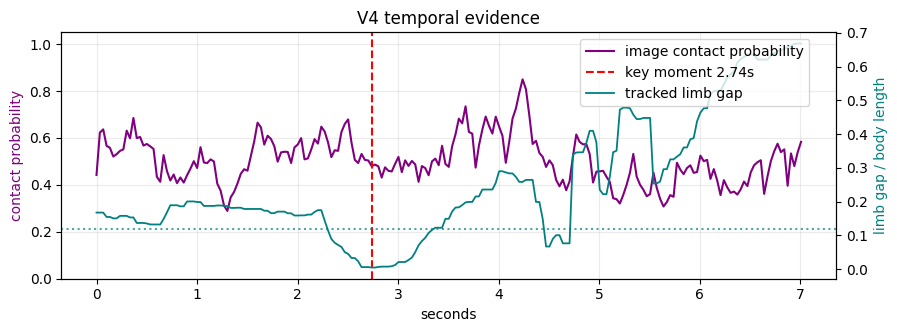

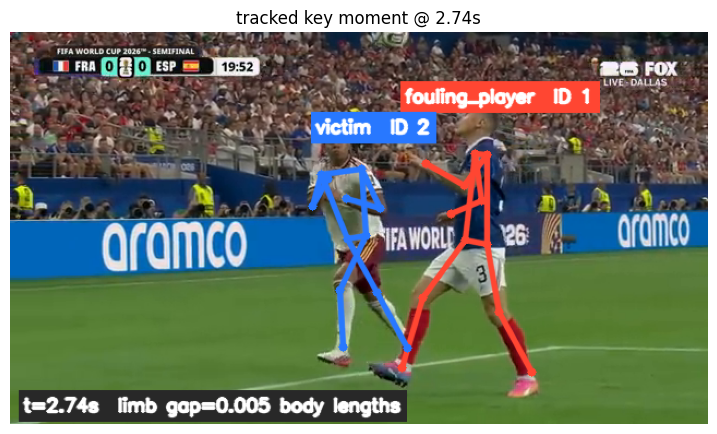

Tracked annotated video:


V4 TRACKED VIDEO VERDICT
  HANDBALL — sustained ball/arm evidence (97%)

frames analyzed: 211
frames with 2+ trackable people: 211/211
persistent role IDs: {'fouling_player': 1, 'victim': 2}
minimum limb gap: 0.005 body lengths
sustained contact duration: 1.07s
contact vote: player_to_ball_contact (45%)
tackle vote: foul (76%)
handball likelihood: 97%
Roboflow calls: 3

Rule: one frame cannot create the video verdict; contact must persist for at least 3 tracked frames.


In [ ]:
from google.colab import files
from IPython.display import Video, display
from airef.video_judge import judge_video

def show_video_result(name, data):
    print('=' * 68)
    print(f'CLIP: {name}')
    result = judge_video(data, progress=print)
    print()
    print('+' + '-' * 66 + '+')
    print(f'|  {result.verdict[:62]:<62}  |')
    print('+' + '-' * 66 + '+')

    ts = [t for t, _ in result.timeline]
    cs = [s for _, s in result.timeline]
    gaps = [g for _, g in result.pose_timeline]
    fig, ax1 = plt.subplots(figsize=(10, 3.2))
    ax1.plot(ts, cs, color='purple', lw=1.5, label='image contact probability')
    ax1.set_xlabel('seconds'); ax1.set_ylabel('contact probability', color='purple')
    ax1.set_ylim(0, 1.05); ax1.grid(alpha=0.25)
    ax2 = ax1.twinx()
    ax2.plot(ts, gaps, color='teal', lw=1.3, label='tracked limb gap')
    ax2.axhline(0.12, color='teal', ls=':', alpha=0.7)
    ax2.set_ylabel('limb gap / body length', color='teal')
    ax1.axvline(result.peak_t, color='red', ls='--', label=f'key moment {result.peak_t:.2f}s')
    fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
    plt.title('V4 temporal evidence'); plt.show()

    if result.peak_annotated is not None:
        plt.figure(figsize=(9, 7))
        plt.imshow(cv2.cvtColor(result.peak_annotated, cv2.COLOR_BGR2RGB))
        plt.axis('off'); plt.title(f'tracked key moment @ {result.peak_t:.2f}s')
        plt.show()
    if result.annotated_video_path:
        print('Tracked annotated video:')
        display(Video(result.annotated_video_path, embed=True))
    print(result.report)
    print('=' * 68)

uploaded_video = files.upload()
for name, data in uploaded_video.items():
    try:
        show_video_result(name, data)
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f'⚠ could not analyze {name}: {type(e).__name__}: {e}')
        print('  checklist: run setup, all writefile cells, model loading, and pre-flight')
